# **Baseline Model for 6050 Project**



# <u> Loading All Packages </u>

In [54]:
import subprocess
subprocess.run(['nvidia-smi'])

Sun Mar 22 15:24:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:A1:00.0 Off |                  N/A |
|  0%   40C    P8             21W /  350W |    2115MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

CompletedProcess(args=['nvidia-smi'], returncode=0)

In [55]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [56]:
pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [57]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import re
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import os
from torchvision import transforms
import os
from collections import Counter


# loading ML packages
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, roc_auc_score
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# <u> Prepping Data Dimensions </u>



In [58]:
BODY_PART_MAP = {
    'ELBOW':    0,
    'FINGER':   1,
    'FOREARM':  2,
    'HAND':     3,
    'HUMERUS':  4,
    'SHOULDER': 5,
    'WRIST':    6,
}
BODY_PARTS   = list(BODY_PART_MAP.keys())
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 4
NORM_MEAN    = [0.485, 0.456, 0.406]
NORM_STD     = [0.229, 0.224, 0.225]

# <u> Connecting to Google Drive </u>



In [59]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [60]:
print('Checking for shared folder in your mounted drive:')
!ls '/content/drive/MyDrive/DeepLearning_DS6050_GroupProject/'

Checking for shared folder in your mounted drive:
ls: cannot access '/content/drive/MyDrive/DeepLearning_DS6050_GroupProject/': No such file or directory


In [61]:
# ── Constants ────────────────────────────────────────────────────────────────

paths_to_try = [
    '/content/drive/MyDrive/DeepLearning_DS6050_GroupProject/',
    '/content/drive/Shareddrives/DeepLearning_DS6050_GroupProject/',
    '/content/drive/MyDrive/Shortcuts/DeepLearning_DS6050_GroupProject/',
    '/mhe3sy/Desktop/',
    './'
    
]

DRIVE_ROOT = None
for path in paths_to_try:
    try:
        os.listdir(path)
        DRIVE_ROOT = path
        print(f"Drive root found at: {DRIVE_ROOT}")
        break
    except FileNotFoundError:
        continue

if DRIVE_ROOT is None:
    print("Could not find project folder. MyDrive contents:")
    print(os.listdir('/content/drive/MyDrive/'))
    raise FileNotFoundError("Please update paths_to_try with the correct path.")

Drive root found at: ./


In [62]:
for csv_file in ['train_image_paths.csv', 'train_labeled_studies.csv',
                 'valid_image_paths.csv', 'valid_labeled_studies.csv']:
    df = pd.read_csv(f"{DRIVE_ROOT}{csv_file}")
    print(f"\n── {csv_file} ──")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(df.head(3).to_string())


── train_image_paths.csv ──
  Shape: (36807, 1)
  Columns: ['MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image1.png']
   MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image1.png
0  MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image2.png
1  MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image3.png
2  MURA-v1.1/train/XR_SHOULDER/patient00002/study1_positive/image1.png

── train_labeled_studies.csv ──
  Shape: (13457, 2)
  Columns: ['image_path', 'label']
                                                  image_path  label
0  MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/      1
1  MURA-v1.1/train/XR_SHOULDER/patient00002/study1_positive/      1
2  MURA-v1.1/train/XR_SHOULDER/patient00003/study1_positive/      1

── valid_image_paths.csv ──
  Shape: (3196, 1)
  Columns: ['MURA-v1.1/valid/XR_WRIST/patient11185/study1_positive/image1.png']
   MURA-v1.1/valid/XR_WRIST/patient11185/study1_positive/image1.png
0  MURA-v1.1/valid/XR_WRIST/

# <u> Path to Data </u>



In [63]:
SHORTCUT_ROOT = Path(DRIVE_ROOT)
TRAIN_IMG_DIR = SHORTCUT_ROOT / 'train'
VALID_IMG_DIR = SHORTCUT_ROOT / 'valid'

print(SHORTCUT_ROOT)

def get_abs_path(image_path_str: str, split: str = 'train') -> Path:
    rel = re.sub(r'^.*?(?:train|valid)/', '', image_path_str)
    return (TRAIN_IMG_DIR if split == 'train' else VALID_IMG_DIR) / rel

.


# <u> Data Loaders </u>



In [64]:
def _add_study_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived columns to a study-level DataFrame (in-place, returns df)."""
    df['image'] = (
        df['image']
        .astype(str)
        .str.replace(r'^MURA-v1\.1/', '', regex=True)
        .str.rstrip('/')
        .str.strip()
    )
    df['patient_id']        = df['image'].str.extract(r'(patient\d+)')[0]
    df['body_part']         = df['image'].str.extract(r'XR_(\w+)/')[0].str.upper()
    df['body_part_encoded'] = df['body_part'].map(BODY_PART_MAP)
    df['inferred_label']    = df['image'].str.contains('positive').astype(int)
    df['study_id']          = df['image'].str.extract(r'(study\d+)')[0]
    return df


def _add_image_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived columns to an image-level DataFrame (in-place, returns df)."""
    df['image'] = (
        df['image']
        .astype(str)
        .str.strip()
    )
    df['patient_id']        = df['image'].str.extract(r'(patient\d+)')[0]
    df['body_part']         = df['image'].str.extract(r'XR_(\w+)/')[0].str.upper()
    df['body_part_encoded'] = df['body_part'].map(BODY_PART_MAP)
    df['abnormality_label'] = df['image'].str.contains('positive').astype(int)
    df['study_id']          = df['image'].str.extract(r'(study\d+)')[0]
    df['study_path'] = (
        df['image']
        .str.replace(r'/image\d+\.(png|jpg|jpeg)$', '', regex=True)
        .str.rstrip('/')
        .str.strip()
    )
    return df


def load_csvs(drive_root: str):
    """Load and preprocess all four CSVs. Returns (train_study_df, valid_study_df,
    train_img_df, valid_img_df)."""
    train_study = pd.read_csv(os.path.join(drive_root, 'train_labeled_studies.csv'))
    valid_study = pd.read_csv(os.path.join(drive_root, 'valid_labeled_studies.csv'))

    # Normalise column name if needed
    for df in (train_study, valid_study):
        if 'image_path' in df.columns:
            df.rename(columns={'image_path': 'image'}, inplace=True)

    train_study = _add_study_cols(train_study)
    valid_study = _add_study_cols(valid_study)

    train_img = pd.read_csv(
        os.path.join(drive_root, 'train_image_paths.csv'), header=None, names=['image']
    )
    valid_img = pd.read_csv(
        os.path.join(drive_root, 'valid_image_paths.csv'), header=None, names=['image']
    )
    train_img = _add_image_cols(train_img)
    valid_img = _add_image_cols(valid_img)

    return train_study, valid_study, train_img, valid_img


train_study_df, valid_study_df, train_img_df, valid_img_df = load_csvs(DRIVE_ROOT)

print(f"Train studies : {len(train_study_df):,} | Valid studies : {len(valid_study_df):,}")
print(f"Train images  : {len(train_img_df):,}  | Valid images  : {len(valid_img_df):,}")
print(f"Train patients: {train_study_df['patient_id'].nunique():,} | "
      f"Valid patients: {valid_study_df['patient_id'].nunique():,}")


Train studies : 13,457 | Valid studies : 1,199
Train images  : 36,808  | Valid images  : 3,197
Train patients: 11,184 | Valid patients: 783


# <u> Strategies for Using Data </u>



## Strategy 1 (each study independent + each image has own observation)

In [65]:
#train_study_paths_clean = set(train_study_df["image"].astype(str)) #train_studies_clean -> Not defined, Kristina might need to check
#valid_study_paths_clean = set(valid_study_df["image"].astype(str)) #valid_studies_clean -> Not defined, Kristina might need to check, replaced with

train_study_paths_clean = set(
    train_study_df["image"].astype(str).apply(lambda x: 'MURA-v1.1/' + x)
)
valid_study_paths_clean = set(
    valid_study_df["image"].astype(str).apply(lambda x: 'MURA-v1.1/' + x)
)

print("Train study paths (normalized):", len(train_study_paths_clean))
print("Valid study paths (normalized):", len(valid_study_paths_clean))
print("Sample:", list(train_study_paths_clean)[:2])

print("Train Set images:", len(train_study_paths_clean))
print("Valid Set images:", len(valid_study_paths_clean))

all_img_df = pd.concat([train_img_df, valid_img_df], axis=0).reset_index(drop=True)

train_set1_df = all_img_df[all_img_df["study_path"].isin(train_study_paths_clean)].copy()
valid_set_df  = all_img_df[all_img_df["study_path"].isin(valid_study_paths_clean)].copy()

print("\nStrategy 1")
print("Train Set 1 images:", len(train_set1_df))
print("Valid images:", len(valid_set_df))
print("Train Set 1 patients:", train_set1_df["patient_id"].nunique())
print("Train Set 1 studies:", train_set1_df["study_path"].nunique())

Train study paths (normalized): 13457
Valid study paths (normalized): 1199
Sample: ['MURA-v1.1/train/XR_WRIST/patient08742/study1_negative', 'MURA-v1.1/train/XR_SHOULDER/patient02645/study1_negative']
Train Set images: 13457
Valid Set images: 1199

Strategy 1
Train Set 1 images: 36808
Valid images: 3197
Train Set 1 patients: 11184
Train Set 1 studies: 13457


##  Strategy 2 (only keep 1 study by patient + each image has own observation)

In [66]:

def keep_one_study_per_patient_positive(study_df):
    study_df = study_df.copy()

    study_df = study_df.sort_values(
        ["patient_id", "inferred_label", "image"],
        ascending=[True, False, True]
    )

    kept_rows = []
    for patient_id, group in study_df.groupby("patient_id"):
        if (group["inferred_label"] == 1).any():
            chosen = group[group["inferred_label"] == 1].iloc[0]
        else:
            chosen = group.iloc[0]
        kept_rows.append(chosen)

    kept_df = pd.DataFrame(kept_rows).reset_index(drop=True)

    assert len(kept_df) == kept_df["patient_id"].nunique()
    return kept_df

train_studies_s2 = keep_one_study_per_patient_positive(train_study_df)

kept_study_paths_s2  = set(train_studies_s2["image"].astype(str).apply(lambda x: 'MURA-v1.1/' + x))
train_set2_df = train_img_df[train_img_df["study_path"].isin(kept_study_paths_s2)].copy()

print("\nStrategy 2")
print("Train Set 2 images:", len(train_set2_df))
print("Train Set 2 patients:", train_set2_df["patient_id"].nunique())
print("Train Set 2 studies:", train_set2_df["study_path"].nunique())
print("Images removed from Set 1 to Set 2:", len(train_set1_df) - len(train_set2_df))


Strategy 2
Train Set 2 images: 30616
Train Set 2 patients: 11184
Train Set 2 studies: 11184
Images removed from Set 1 to Set 2: 6192


In [67]:
print("\nComparison Check")
print("Patients in original train studies:", train_study_df["patient_id"].nunique())
print("Patients in Strategy 2:", train_set2_df["patient_id"].nunique())

missing = set(train_study_df["patient_id"]) - set(train_set2_df["patient_id"])
print("Patients missing from Strategy 2:", len(missing))


Comparison Check
Patients in original train studies: 11184
Patients in Strategy 2: 11184
Patients missing from Strategy 2: 0


# <u> EDA </u>


### **EDA — Checking Patient Overlap**

In [68]:
train_patients = set(train_study_df['patient_id'].unique())
valid_patients = set(valid_study_df['patient_id'].unique())
overlap        = train_patients & valid_patients

print(f"\nCheck Patients in Train / Validation Split:")
print(f"  Train patients      : {len(train_patients):,}")
print(f"  Validation patients : {len(valid_patients):,}")
print(f"  Overlap             : {len(overlap):,}")
print(f"  Train-only          : {len(train_patients - valid_patients):,}")
print(f"  Valid-only          : {len(valid_patients - train_patients):,}")

if overlap:
    print(f"\n⚠ WARNING: {len(overlap)} patients appear in BOTH sets (data leakage risk)")
    # Summarise overlapping patients
    overlap_train = train_study_df[train_study_df['patient_id'].isin(overlap)].copy()
    overlap_valid = valid_study_df[valid_study_df['patient_id'].isin(overlap)].copy()
    train_summary = (
        overlap_train.groupby('patient_id')
        .agg(
            n_train_studies        =('image',          'nunique'),
            train_positive_studies =('inferred_label', lambda x: int((x == 1).sum())),
            train_negative_studies =('inferred_label', lambda x: int((x == 0).sum())),
        )
        .reset_index()
    )
    valid_summary = (
        overlap_valid.groupby('patient_id')
        .agg(
            n_valid_studies        =('image',          'nunique'),
            valid_positive_studies =('inferred_label', lambda x: int((x == 1).sum())),
            valid_negative_studies =('inferred_label', lambda x: int((x == 0).sum())),
        )
        .reset_index()
    )
    overlap_summary = train_summary.merge(valid_summary, on='patient_id', how='outer')
    overlap_summary['total_studies'] = (
        overlap_summary['n_train_studies'].fillna(0) +
        overlap_summary['n_valid_studies'].fillna(0)
    )
    print("\nOverlap summary (first 10 rows):")
    print(overlap_summary.head(10))
else:
    print("\n✓ No patient overlap — clean train/valid split (no data leakage)")


Check Patients in Train / Validation Split:
  Train patients      : 11,184
  Validation patients : 783
  Overlap             : 0
  Train-only          : 11,184
  Valid-only          : 783

✓ No patient overlap — clean train/valid split (no data leakage)


### **EDA — Checking Class Balance and Conflicting Patients**

In [69]:
# --- TRAIN ---
counts = train_study_df.groupby(['body_part', 'inferred_label']).size().unstack(fill_value=0)
print(counts)

#train_study_df['patient'] = train_study_df['image'].str.extract(r'(MURA-v1\.1/(?:train|valid)/XR_\w+/patient\d+/)')
#train_study_df['inferred_label'] = train_study_df['image'].str.contains('positive').astype(int)

label_counts = train_study_df.groupby('patient_id')['inferred_label'].nunique()
conflicted = label_counts[label_counts > 1].index.tolist()
print(f"Number of conflicted patients: {len(conflicted)}")

# --- VALIDATION ---
counts = valid_study_df.groupby(['body_part', 'inferred_label']).size().unstack(fill_value=0)
print(counts)

#valid_study_df['patient'] = valid_study_df['image'].str.extract(r'(MURA-v1\.1/(?:train|valid)/XR_\w+/patient\d+/)')
#valid_study_df['inferred_label'] = valid_study_df['image'].str.contains('positive').astype(int)

label_counts = valid_study_df.groupby('patient_id')['inferred_label'].nunique()
conflicted = label_counts[label_counts > 1].index.tolist()
print(f"Number of conflicted patients: {len(conflicted)}")

inferred_label     0     1
body_part                 
ELBOW           1094   660
FINGER          1280   655
FOREARM          590   287
HAND            1497   521
HUMERUS          321   271
SHOULDER        1364  1457
WRIST           2134  1326
Number of conflicted patients: 888
inferred_label    0   1
body_part              
ELBOW            92  66
FINGER           92  83
FOREARM          69  64
HAND            101  66
HUMERUS          68  67
SHOULDER         99  95
WRIST           140  97
Number of conflicted patients: 167


### **EDA — Dataset Summary**

In [70]:
#train_study_df = pd.read_csv(train_study_df_CSV)
#train_study_df.rename(columns={'image_path': 'study_path'}, inplace=True)

#valid_study_df = pd.read_csv(valid_study_df_CSV)
#valid_study_df.rename(columns={'image': 'study_path'}, inplace=True)

# Extract body part and patient ID from path
#def parse_path(df):
#    df = df.copy()
#    df['body_part']  = df['image'].str.extract(r'XR_([A-Z]+)/')[0]
#    df['patient_id'] = df['image'].str.extract(r'(patient\d+)/')[0]
#    df['split']      = df['image'].str.extract(r'MURA-v1\.1/(\w+)/')[0]
#    return df

#train_study_df = parse_path(train_study_df)
#valid_study_df = parse_path(valid_study_df)

print(f'Train studies : {len(train_study_df):,}')
print(f'Valid studies : {len(valid_study_df):,}')
print(f'Train patients: {train_study_df.patient_id.nunique():,}')
print(f'Valid patients: {valid_study_df.patient_id.nunique():,}')
print()
print('Train studies preview:')
train_study_df.head(3)

Train studies : 13,457
Valid studies : 1,199
Train patients: 11,184
Valid patients: 783

Train studies preview:


,image,label,patient_id,body_part,body_part_encoded,inferred_label,study_id
0,train/XR_SHOULDER/patient00001/study1_positive,1,patient00001,SHOULDER,5,1,study1
1,train/XR_SHOULDER/patient00002/study1_positive,1,patient00002,SHOULDER,5,1,study1
2,train/XR_SHOULDER/patient00003/study1_positive,1,patient00003,SHOULDER,5,1,study1


### **EDA — Class Balance Table (Study Level)**

In [71]:
def class_balance_table(df, title=''):
    tbl = df.groupby(['body_part','inferred_label']).size().unstack(fill_value=0)
    tbl.columns = ['Negative (0)', 'Positive (1)']
    tbl['Total']    = tbl.sum(axis=1)
    tbl['Pos Rate'] = (tbl['Positive (1)'] / tbl['Total'] * 100).round(1)
    tbl = tbl.sort_values('Total', ascending=False)
    totrow = tbl.sum(numeric_only=True)
    totrow['Pos Rate'] = round(totrow['Positive (1)'] / totrow['Total'] * 100, 1)
    tbl.loc['TOTAL'] = totrow
    print(f'\n{title}')
    print(tbl.to_string())
    return tbl

train_balance = class_balance_table(train_study_df, '── TRAIN (study level) ──')
valid_balance = class_balance_table(valid_study_df, '── VALID (study level) ──')



── TRAIN (study level) ──
           Negative (0)  Positive (1)    Total  Pos Rate
body_part                                               
WRIST            2134.0        1326.0   3460.0      38.3
SHOULDER         1364.0        1457.0   2821.0      51.6
HAND             1497.0         521.0   2018.0      25.8
FINGER           1280.0         655.0   1935.0      33.9
ELBOW            1094.0         660.0   1754.0      37.6
FOREARM           590.0         287.0    877.0      32.7
HUMERUS           321.0         271.0    592.0      45.8
TOTAL            8280.0        5177.0  13457.0      38.5

── VALID (study level) ──
           Negative (0)  Positive (1)   Total  Pos Rate
body_part                                              
WRIST             140.0          97.0   237.0      40.9
SHOULDER           99.0          95.0   194.0      49.0
FINGER             92.0          83.0   175.0      47.4
HAND              101.0          66.0   167.0      39.5
ELBOW              92.0          66.0   

### **EDA — Class Balance Bar Chart by Body Part**

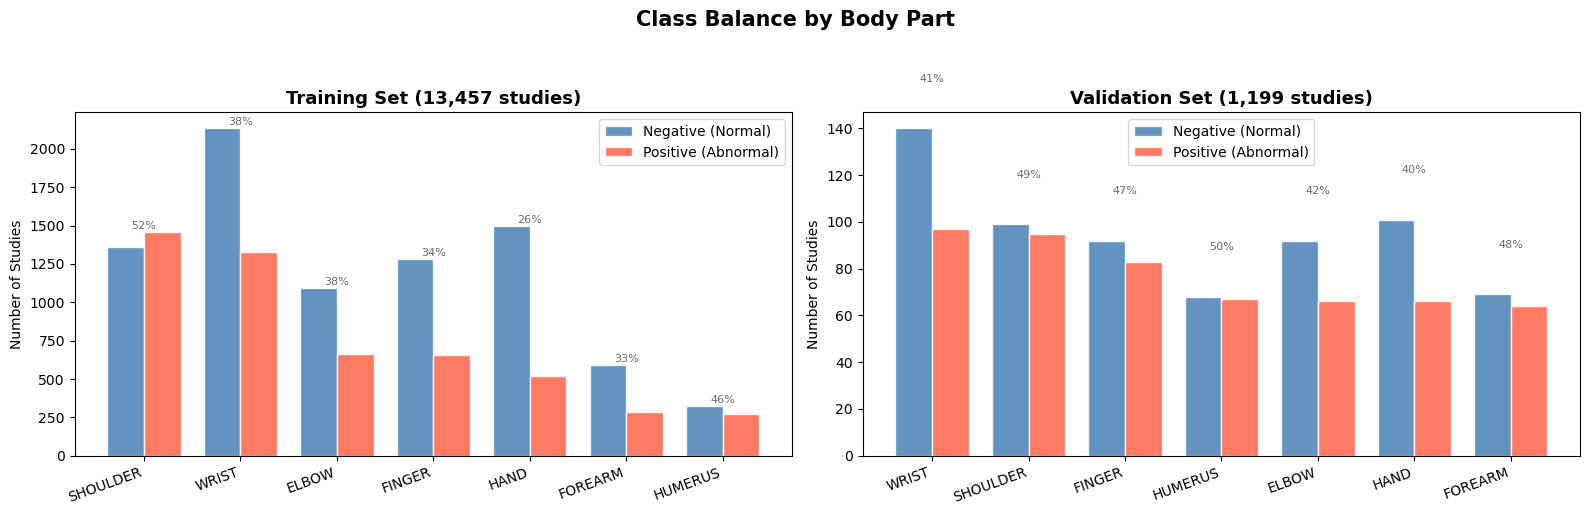

In [72]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, title in zip(axes,
                          [train_study_df, valid_study_df],
                          ['Training Set (13,457 studies)', 'Validation Set (1,199 studies)']):
    counts = df.groupby(['body_part', 'inferred_label']).size().unstack(fill_value=0)
    counts.columns = ['Negative', 'Positive']
    counts = counts.sort_values('Positive', ascending=False)

    x = np.arange(len(counts))
    w = 0.38
    b1 = ax.bar(x - w/2, counts['Negative'], w, label='Negative (Normal)',
                color='steelblue', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + w/2, counts['Positive'], w, label='Positive (Abnormal)',
                color='tomato', alpha=0.85, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(counts.index, rotation=20, ha='right', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Studies')
    ax.legend()

    for i, (neg, pos) in enumerate(zip(counts['Negative'], counts['Positive'])):
        rate = pos / (pos + neg) * 100
        ax.text(i, max(neg, pos) + 20, f'{rate:.0f}%', ha='center', fontsize=8, color='dimgray')

plt.suptitle('Class Balance by Body Part', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_balance.png', bbox_inches='tight')
plt.show()

### **EDA — Images per Study Distribution**

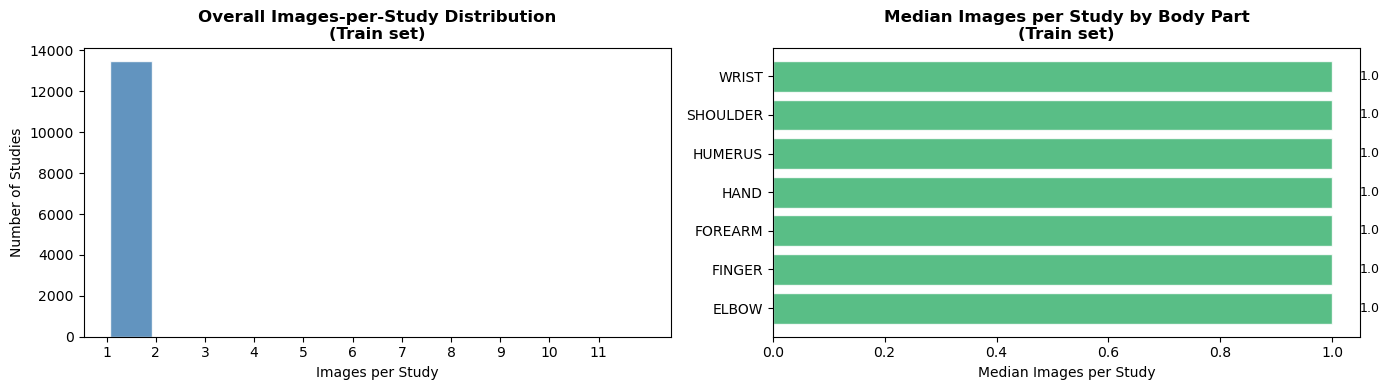

count    13457.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0

Studies with only 1 image: 13457 (100.0%)


In [73]:
imgs_per_study = (train_study_df.groupby('image').size()
                  .reset_index(name='n_images'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(imgs_per_study['n_images'], bins=range(1, 13),
             color='steelblue', edgecolor='white', alpha=0.85, rwidth=0.85)
axes[0].set_xlabel('Images per Study')
axes[0].set_ylabel('Number of Studies')
axes[0].set_title('Overall Images-per-Study Distribution\n(Train set)', fontweight='bold')
axes[0].set_xticks(range(1, 12))

train_study_df2 = train_study_df.copy()
train_study_df2['n_imgs'] = train_study_df2.groupby('image')['image'].transform('count')
median_per_bp = (train_study_df2.groupby('body_part')['n_imgs']
                 .median().sort_values(ascending=False))

axes[1].barh(median_per_bp.index, median_per_bp.values,
             color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Median Images per Study')
axes[1].set_title('Median Images per Study by Body Part\n(Train set)', fontweight='bold')
for i, v in enumerate(median_per_bp.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(imgs_per_study['n_images'].describe().round(2).to_string())
print(f"\nStudies with only 1 image: {(imgs_per_study['n_images']==1).sum()} ({(imgs_per_study['n_images']==1).mean()*100:.1f}%)")


### **EDA - File Path Resolution & Image Access Test**

TRAIN_IMG_DIR exists: True
VALID_IMG_DIR exists: True
train
valid

Resolved: train/XR_ELBOW/patient00646/study1_positive/image1.png
Exists  : True


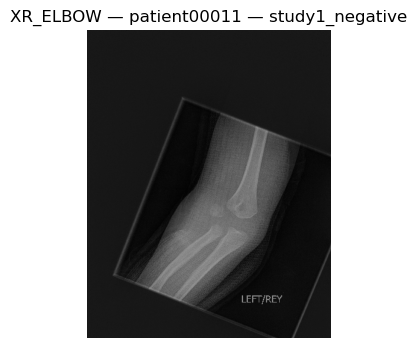

In [74]:
# Resolving absolute file paths

# Visually testing

# DRIVE_ROOT already points to that folder
# The shortcut path in this code is stale from an older version of the notebook



print(f"TRAIN_IMG_DIR exists: {TRAIN_IMG_DIR.exists()}")
print(f"VALID_IMG_DIR exists: {VALID_IMG_DIR.exists()}")

print(TRAIN_IMG_DIR)
print(VALID_IMG_DIR)

# ── Test ──────────────────────────────────────────────────────────────────────

test = 'train/XR_ELBOW/patient00646/study1_positive/image1.png'

resolved = get_abs_path(test, split='train')
print(f"\nResolved: {resolved}")
print(f"Exists  : {resolved.exists()}")

if resolved.exists():
    img = Image.open(resolved).convert('RGB')
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title('XR_ELBOW — patient00011 — study1_negative')
    plt.axis('off')
    plt.show()

### **EDA — Sample X-Rays by Body Part (Normal vs Abnormal)**

train/XR_ELBOW/patient04938/study2_negative/image1.png
train/XR_ELBOW/patient04938/study2_negative/image2.png
train/XR_ELBOW/patient04938/study2_negative/image3.png
train/XR_ELBOW/patient00894/study2_negative/image1.png
train/XR_ELBOW/patient00894/study2_negative/image2.png
train/XR_ELBOW/patient04903/study1_positive/image1.png
train/XR_ELBOW/patient04904/study1_positive/image1.png
train/XR_ELBOW/patient04904/study1_positive/image2.png
train/XR_ELBOW/patient04905/study1_positive/image1.png
train/XR_ELBOW/patient04905/study1_positive/image2.png
train/XR_FINGER/patient03230/study2_negative/image1.png
train/XR_FINGER/patient03230/study2_negative/image2.png
train/XR_FINGER/patient03230/study2_negative/image3.png
train/XR_FINGER/patient03242/study2_negative/image1.png
train/XR_FINGER/patient03242/study2_negative/image2.png
train/XR_FINGER/patient03227/study1_positive/image1.png
train/XR_FINGER/patient03227/study1_positive/image2.png
train/XR_FINGER/patient03227/study1_positive/image3.png
tr

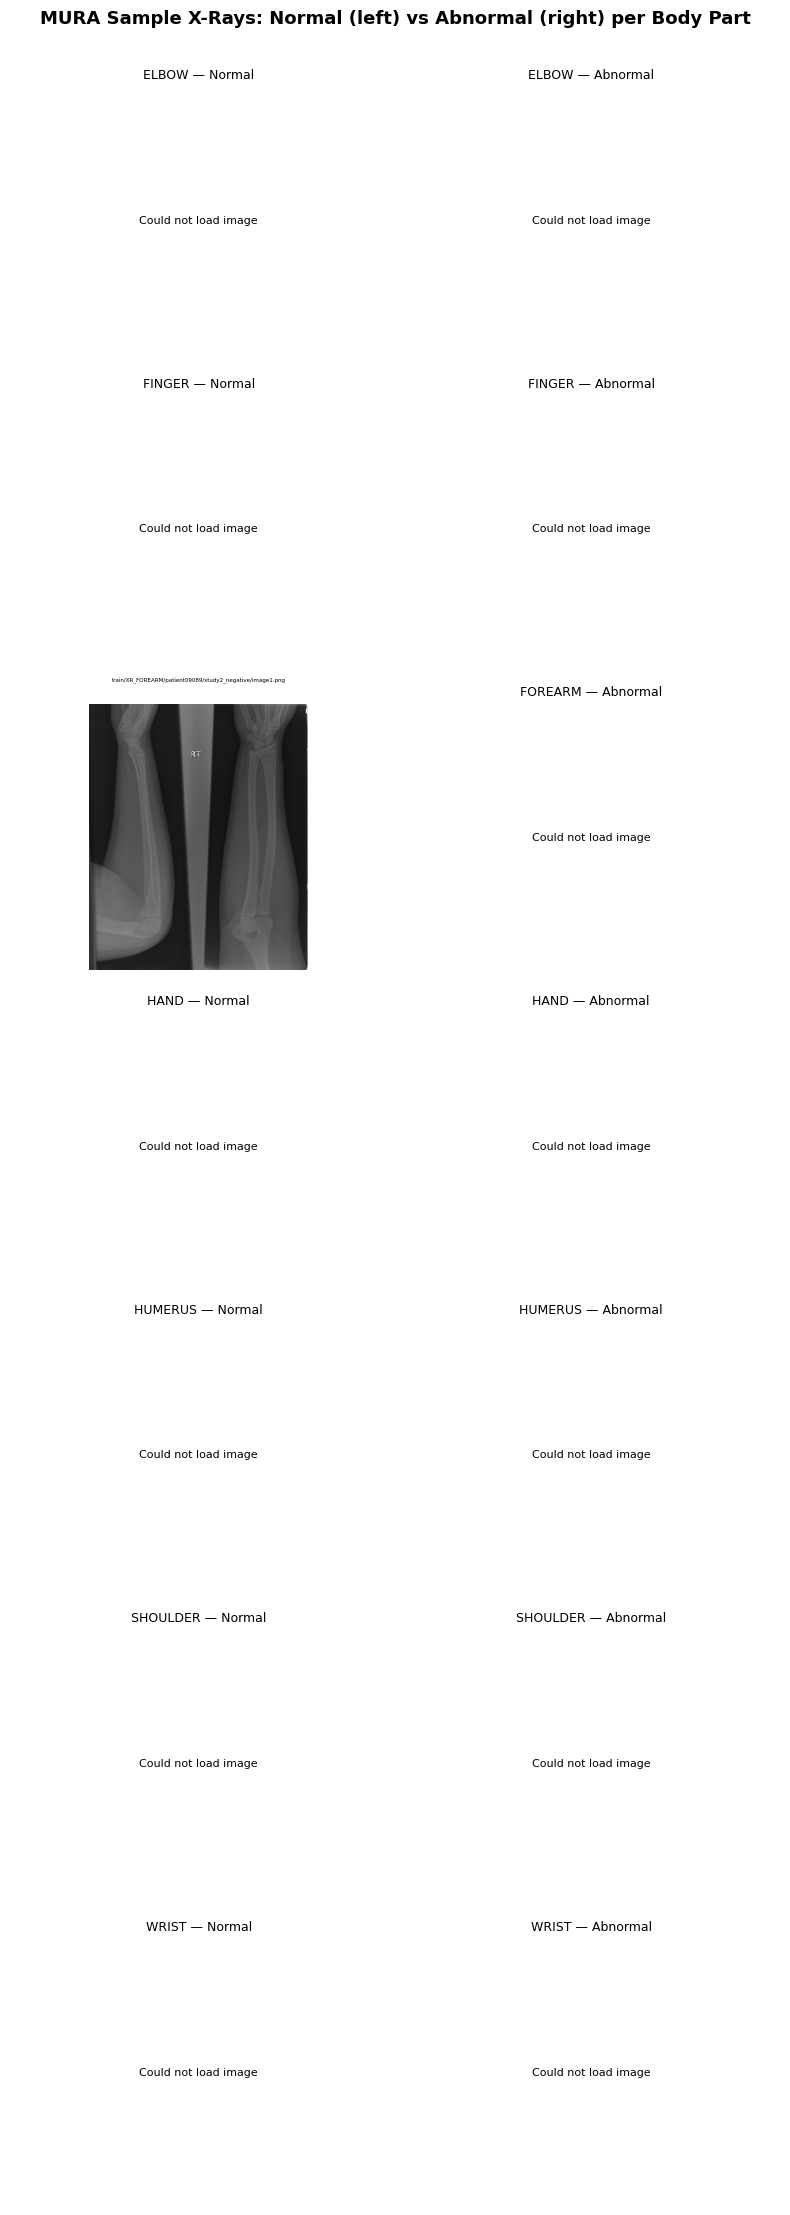

In [75]:
BODY_PARTS = ['ELBOW', 'FINGER', 'FOREARM', 'HAND', 'HUMERUS', 'SHOULDER', 'WRIST']

fig, axes = plt.subplots(7, 2, figsize=(8, 22))
fig.suptitle('MURA Sample X-Rays: Normal (left) vs Abnormal (right) per Body Part',
             fontsize=13, fontweight='bold', y=1.005)

for row_idx, bp in enumerate(BODY_PARTS):
    for col_idx, lbl in enumerate([0, 1]):
        ax = axes[row_idx, col_idx]
        subset = train_img_df[(train_img_df['body_part'] == bp) &
                               (train_img_df['abnormality_label'] == lbl)]
        lbl_str = 'Abnormal' if lbl == 1 else 'Normal'
        ax.set_title(f'{bp} — {lbl_str}', fontsize=9)

        if len(subset) == 0:
            ax.text(0.5, 0.5, 'No samples', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
            ax.axis('off')
            continue

        loaded = False
        for i in range(min(5, len(subset))):
            try:
                img_path = get_abs_path(subset.iloc[i]['image'], split='train')  # ← fixed
                print(img_path)
                img = Image.open(img_path).convert('RGB')
                ax.imshow(img, cmap='gray')
                ax.set_title(f"{img_path}", fontsize=4, pad=16)
                loaded = True
                break
            except Exception:
                continue

        if not loaded:
            ax.text(0.5, 0.5, 'Could not load image',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

### **EDA — Image Size and Resolution Distribution**

Reading sizes:   0%|          | 0/500 [00:00<?, ?it/s]

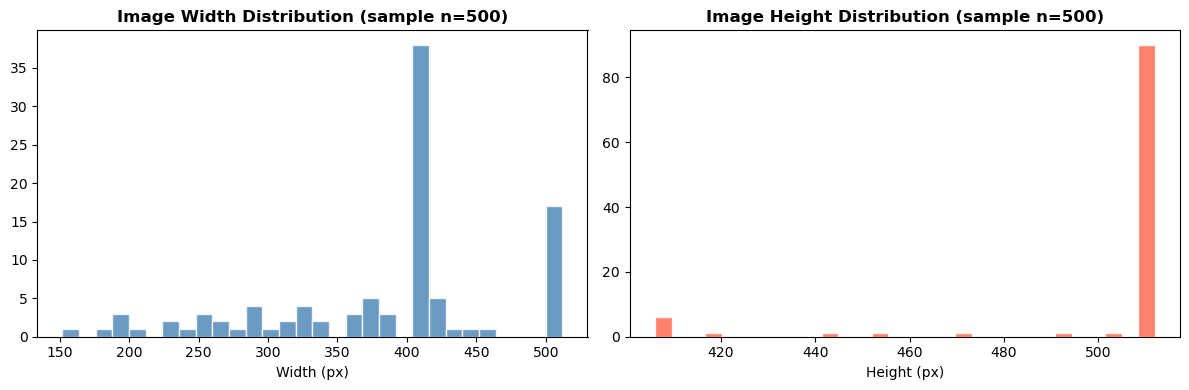

Width  — mean: 384px, median: 406px, range: [152, 512]
Height — mean: 503px, median: 512px, range: [406, 512]


In [76]:
from tqdm.auto import tqdm

sample_df = train_img_df.sample(min(500, len(train_img_df)))
heights, widths = [], []

for path in tqdm(sample_df['image'], desc='Reading sizes'):  # ← 'image' not 'image_path'
    try:
        img_path = get_abs_path(path, split='train')  # ← use loop variable directly
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
    except:
        pass

if widths:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].set_title('Image Width Distribution (sample n=500)', fontweight='bold')
    axes[0].set_xlabel('Width (px)')
    axes[1].hist(heights, bins=30, color='tomato', edgecolor='white', alpha=0.8)
    axes[1].set_title('Image Height Distribution (sample n=500)', fontweight='bold')
    axes[1].set_xlabel('Height (px)')
    plt.tight_layout()
    plt.savefig('eda_image_sizes.png', bbox_inches='tight')
    plt.show()
    print(f'Width  — mean: {np.mean(widths):.0f}px, median: {np.median(widths):.0f}px, range: [{min(widths)}, {max(widths)}]')
    print(f'Height — mean: {np.mean(heights):.0f}px, median: {np.median(heights):.0f}px, range: [{min(heights)}, {max(heights)}]')
else:
    print('Images not found on disk — skipping size analysis.')

### **EDA - Pixel Intensity Distribution: Normal vs Abnormal**

/tmp/ipykernel_907208/660318793.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_n = train_img_df.groupby('abnormality_label').apply(


Loading pixels:   0%|          | 0/160 [00:00<?, ?it/s]

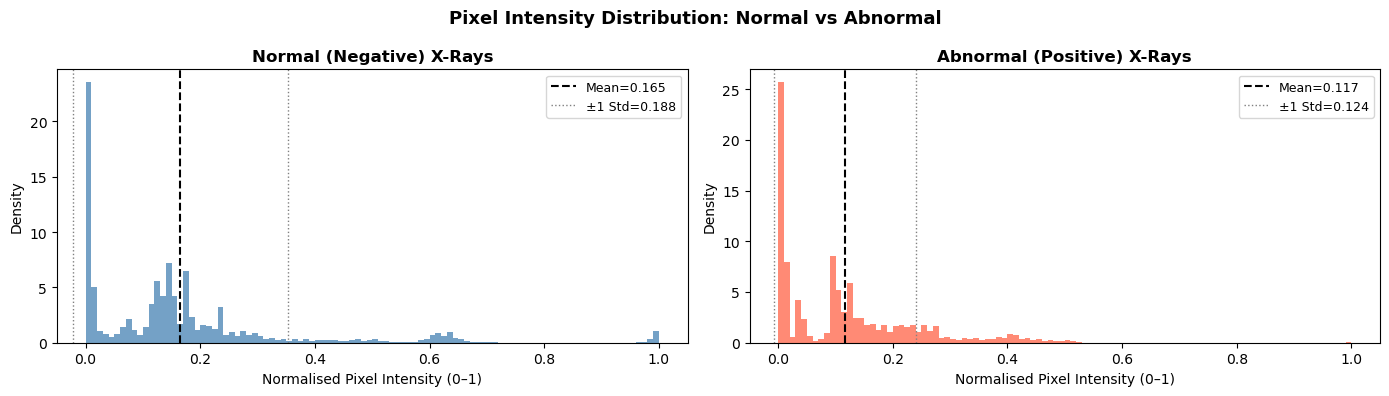

Mean pixel intensities — Normal: 0.165  | Abnormal: 0.1172
Std  pixel intensities — Normal: 0.1878  | Abnormal: 0.1241

Note: Both distributions are dark-skewed (large dark background).
ImageNet normalisation (mean=[0.485,0.456,0.406]) is a reasonable starting point.


In [77]:
# EDA — Pixel Intensity Analysis
sample_n = train_img_df.groupby('abnormality_label').apply(
    lambda x: x.sample(min(80, len(x)))
).reset_index(drop=True)

all_pixels = {0: [], 1: []}
for _, row in tqdm(sample_n.iterrows(), total=len(sample_n), desc='Loading pixels'):
    try:
        img_path = get_abs_path(row['image'], split='train')  # ← fixed
        img = Image.open(img_path).convert('L')
        arr = np.array(img).flatten() / 255.0
        all_pixels[row['abnormality_label']].extend(arr[:5000])
    except:
        pass

if all_pixels[0] and all_pixels[1]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, lbl, color, title in zip(
        axes, [0, 1], ['steelblue', 'tomato'],
        ['Normal (Negative) X-Rays', 'Abnormal (Positive) X-Rays']
    ):
        pixels = np.array(all_pixels[lbl])
        ax.hist(pixels, bins=100, color=color, alpha=0.75, density=True, edgecolor='none')
        ax.axvline(pixels.mean(), color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean={pixels.mean():.3f}')
        ax.axvline(pixels.mean() + pixels.std(), color='gray', linestyle=':', linewidth=1,
                   label=f'±1 Std={pixels.std():.3f}')
        ax.axvline(pixels.mean() - pixels.std(), color='gray', linestyle=':', linewidth=1)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Normalised Pixel Intensity (0–1)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
    plt.suptitle('Pixel Intensity Distribution: Normal vs Abnormal', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_pixel_intensity.png', bbox_inches='tight')
    plt.show()
    print('Mean pixel intensities — Normal:', round(np.mean(all_pixels[0]),4),
          ' | Abnormal:', round(np.mean(all_pixels[1]),4))
    print('Std  pixel intensities — Normal:', round(np.std(all_pixels[0]),4),
          ' | Abnormal:', round(np.std(all_pixels[1]),4))
    print('\nNote: Both distributions are dark-skewed (large dark background).')
    print('ImageNet normalisation (mean=[0.485,0.456,0.406]) is a reasonable starting point.')
else:
    print('Images not found on disk — skipping intensity analysis.')

# <u> Calc Class Weights</u>

In [78]:
pos_count  = (train_study_df['inferred_label'] == 1).sum()
neg_count  = (train_study_df['inferred_label'] == 0).sum()
total      = len(train_study_df)
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float)

print(f"\nTrain images — Negative: {neg_count:,} | Positive: {pos_count:,}")
print(f"Overall positive rate  : {pos_count / total * 100:.1f}%")
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight.item():.4f}")

sample_weights = train_study_df['inferred_label'].map({0: 1.0, 1: float(pos_weight.item())}).values
print(f"Sample weight range: [{sample_weights.min():.2f}, {sample_weights.max():.2f}]")


Train images — Negative: 8,280 | Positive: 5,177
Overall positive rate  : 38.5%
pos_weight for BCEWithLogitsLoss: 1.5994
Sample weight range: [1.00, 1.60]


# <u> Transform Data</u>

In [79]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

In [80]:
# ── Step 1: Check the raw master DataFrame ───────────────────────────────
print("master df shape:", df.shape)
print("columns:", df.columns.tolist())
print("\nSample rows:")
print(df.head(3).to_string())

# ── Step 2: Check what the 'image' paths actually look like ──────────────
print("\nSample image paths:")
print(df['image'].head(5).tolist())

# ── Step 3: Check if there's a 'split' column and its unique values ──────
if 'split' in df.columns:
    print("\nUnique split values:", df['split'].unique())
    print("Value counts:\n", df['split'].value_counts())
else:
    print("\nNo 'split' column found — split must come from the image path string")

# ── Step 4: Check if image paths contain 'train' / 'valid' ───────────────
print("\nPaths containing 'train':", df['image'].str.contains('train', case=False).sum())
print("Paths containing 'valid':", df['image'].str.contains('valid', case=False).sum())
print("Paths containing 'MURA' :", df['image'].str.contains('MURA',  case=False).sum())

master df shape: (1199, 7)
columns: ['image', 'label', 'patient_id', 'body_part', 'body_part_encoded', 'inferred_label', 'study_id']

Sample rows:
                                         image  label    patient_id body_part  body_part_encoded  inferred_label study_id
0  valid/XR_WRIST/patient11185/study1_positive      1  patient11185     WRIST                  6               1   study1
1  valid/XR_WRIST/patient11186/study1_positive      1  patient11186     WRIST                  6               1   study1
2  valid/XR_WRIST/patient11186/study2_positive      1  patient11186     WRIST                  6               1   study2

Sample image paths:
['valid/XR_WRIST/patient11185/study1_positive', 'valid/XR_WRIST/patient11186/study1_positive', 'valid/XR_WRIST/patient11186/study2_positive', 'valid/XR_WRIST/patient11186/study3_positive', 'valid/XR_WRIST/patient11187/study1_positive']

No 'split' column found — split must come from the image path string

Paths containing 'train': 0
Paths con

In [81]:
print("train_set1_df shape:", train_set1_df.shape)
print("train_set2_df shape:", train_set2_df.shape)
print("valid_set_df shape :", valid_set_df.shape)
print()
print("train_set1_df columns:", train_set1_df.columns.tolist())
print()
display(train_set1_df.head(3))
display(valid_set_df.head(3))

train_set1_df shape: (36808, 7)
train_set2_df shape: (30616, 7)
valid_set_df shape : (3197, 7)

train_set1_df columns: ['image', 'patient_id', 'body_part', 'body_part_encoded', 'abnormality_label', 'study_id', 'study_path']



,image,patient_id,body_part,body_part_encoded,abnormality_label,study_id,study_path
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,patient00001,SHOULDER,5,1,study1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...
1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,patient00001,SHOULDER,5,1,study1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...
2,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,patient00001,SHOULDER,5,1,study1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...


,image,patient_id,body_part,body_part_encoded,abnormality_label,study_id,study_path
36808,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...,patient11185,WRIST,6,1,study1,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...
36809,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...,patient11185,WRIST,6,1,study1,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...
36810,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...,patient11185,WRIST,6,1,study1,MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...


# <u> Data Loaders</u>

In [82]:
class MURADataset(Dataset):
    def __init__(self, df, split='train', transform=None):
        self.df        = df.reset_index(drop=True)
        self.split     = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = get_abs_path(row['image'], split=self.split)
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color=0)  # blank fallback

        if self.transform:
            image = self.transform(image)

        label     = torch.tensor(int(row['abnormality_label']),             dtype=torch.long)
        body_part = torch.tensor(int(row['body_part_encoded']), dtype=torch.long)
        return image, label, body_part

    def get_labels(self):
        return self.df['abnormality_label'].astype(int).tolist()


# ── WeightedRandomSampler builder ─────────────────────────────────────────────
def make_sampler(dataset):
    labels        = dataset.get_labels()
    class_counts  = Counter(labels)
    class_weights = {cls: 1.0 / cnt for cls, cnt in class_counts.items()}
    sample_wts    = [class_weights[l] for l in labels]
    return WeightedRandomSampler(sample_wts, num_samples=len(sample_wts), replacement=True)


# ── DataLoader builder ────────────────────────────────────────────────────────
def make_dataloaders(train_df, valid_df, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_dataset = MURADataset(train_df, split='train', transform=train_transform)
    valid_dataset = MURADataset(valid_df, split='valid', transform=val_transform)

    sampler = make_sampler(train_dataset)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,                            # replaces shuffle=True
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(num_workers > 0),
    )
    val_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(num_workers > 0),
    )
    return train_loader, val_loader    


train_loader_s1, val_loader_s1 = make_dataloaders(train_set1_df, valid_set_df)
train_loader_s2, val_loader_s2 = make_dataloaders(train_set2_df, valid_set_df)

for name, train_loader, val_loader, train_df in [
    ("Strategy 1 (all studies, each image independent)",          train_loader_s1, val_loader_s1, train_set1_df),
    ("Strategy 2 (1 study per patient, each image independent)",  train_loader_s2, val_loader_s2, train_set2_df),
]:
    pos = (train_df['abnormality_label'] == 1).sum()
    neg = (train_df['abnormality_label'] == 0).sum()
    print(f"\n{name}")
    print(f"  Train images        : {len(train_df):,}  "
          f"(pos={pos:,}, neg={neg:,}, rate={pos / len(train_df) * 100:.1f}%)")
    print(f"  Valid images        : {len(valid_set_df):,}")
    print(f"  Train batches/epoch : {len(train_loader):,}")
    print(f"  Val   batches/epoch : {len(val_loader):,}")

print("\n── Batch sanity check ──")
for name, loader in [("S1", train_loader_s1), ("S2", train_loader_s2)]:
    imgs, lbls, bps = next(iter(loader))
    print(f"  {name} — shape: {imgs.shape}  "
          f"labels: {lbls[:6].tolist()}  "
          f"parts: {[BODY_PARTS[b] for b in bps[:6].tolist()]}")


Strategy 1 (all studies, each image independent)
  Train images        : 36,808  (pos=14,873, neg=21,935, rate=40.4%)
  Valid images        : 3,197
  Train batches/epoch : 1,151
  Val   batches/epoch : 100

Strategy 2 (1 study per patient, each image independent)
  Train images        : 30,616  (pos=13,795, neg=16,821, rate=45.1%)
  Valid images        : 3,197
  Train batches/epoch : 957
  Val   batches/epoch : 100

── Batch sanity check ──
  S1 — shape: torch.Size([32, 3, 224, 224])  labels: [1, 1, 1, 1, 0, 0]  parts: ['FINGER', 'WRIST', 'ELBOW', 'SHOULDER', 'FINGER', 'FINGER']
  S2 — shape: torch.Size([32, 3, 224, 224])  labels: [0, 1, 0, 1, 0, 1]  parts: ['ELBOW', 'WRIST', 'SHOULDER', 'SHOULDER', 'ELBOW', 'HAND']


train_set1_df -> Strategy 1 image-level DataFrame — all studies, each image as own observation

train_set2_df -> Strategy 2 image-level DataFrame — 1 study per patient

valid_set_df -> Validation image-level DataFrame — shared across both strategies

train_loader_s1 -> PyTorch DataLoader built from train_set1_df

val_loader_s1 -> PyTorch DataLoader built from valid_set_df (Strategy 1)

train_loader_s2 -> PyTorch DataLoader built from train_set2_df

val_loader_s2 -> PyTorch DataLoader built from valid_set_df (Strategy 2)

# <u> Generating the Models </u>
We are generating four models:
1. ResNet50, single classification (abnormality)
2. ResNet50, double classification (abnormality & body part)
3. ConvNeXT, single classification (abnormality)
4. ConvNeXT, double classification (abnormality & body part)

## **ResNet50, single classification (abnormality)**

In [83]:
class Single_ResNet(nn.Module): # single classification on abnormality
    def __init__(self):
        super().__init__()
        self.resnet_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = self.resnet_backbone.fc.in_features
        self.resnet_backbone.fc = nn.Identity() # replaces classificaiton head with empty layer
        self.abnormal_head = nn.Linear(in_features, 1) # 1 abnormality porbability

    def forward(self, x):
        features = self.resnet_backbone(x)
        abnormal_logits = self.abnormal_head(features).squeeze(1)
        return abnormal_logits

# set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# initialize the resnet model, pretrained
single_resnet = Single_ResNet().to(device)

# freeze backbone of baseline pretrained model
for param1 in single_resnet.resnet_backbone.parameters():
    param1.requires_grad = False

# unfreeze last layer
for param2 in single_resnet.resnet_backbone.layer4.parameters():
    param2.requires_grad = True
# train the heads
for param4 in single_resnet.abnormal_head.parameters():
    param4.requires_grad = True

# calc loss
# BCE for abnormal classicication
single_resnet_abnormal_loss_fn = nn.BCEWithLogitsLoss()

# optimize using Adam
single_resnet_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, single_resnet.parameters()),
    lr=1e-4)

## **ResNet50, double classification (abnormality & body part)**


In [84]:
class Multi_ResNet(nn.Module): # multi because it does two different classifications
    def __init__(self):
        super().__init__()
        self.resnet_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = self.resnet_backbone.fc.in_features
        self.resnet_backbone.fc = nn.Identity() # replaces classificaiton head with empty layer

        self.body_part_head = nn.Linear(in_features, 7) # 7 body part
        self.abnormal_head = nn.Linear(in_features, 1) # 1 abnormality porbability

    def forward(self, x):
        features = self.resnet_backbone(x)
        body_part_logits = self.body_part_head(features)
        abnormal_logits = self.abnormal_head(features).squeeze(1)
        return body_part_logits, abnormal_logits

# set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# initialize the resnet model, pretrained
multi_resnet = Multi_ResNet().to(device)

# freeze backbone of baseline pretrained model
for param1 in multi_resnet.resnet_backbone.parameters():
    param1.requires_grad = False

# unfreeze last layer
for param2 in multi_resnet.resnet_backbone.layer4.parameters():
    param2.requires_grad = True
# train the heads
for param3 in multi_resnet.body_part_head.parameters():
    param3.requires_grad = True
for param4 in multi_resnet.abnormal_head.parameters():
    param4.requires_grad = True

# calc loss
# BCE for abnormal classicication, regular CE for body part
multi_resnet_body_loss_fn = nn.CrossEntropyLoss()
multi_resnet_abnormal_loss_fn = nn.BCEWithLogitsLoss()

# optimize using Adam
multi_resnet_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, multi_resnet.parameters()),
    lr=1e-4)

## **ConvNeXT, single classification (abnormality)**

In [85]:
class Single_ConvNeXt(nn.Module):  # single classification on abnormality
    def __init__(self):
        super().__init__()

        # load pretrained ConvNeXt
        self.convnext_backbone = convnext_tiny(
        weights=ConvNeXt_Tiny_Weights.DEFAULT)
        in_features = self.convnext_backbone.classifier[2].in_features
        self.convnext_backbone.classifier = nn.Identity()
        self.abnormal_head = nn.Linear(in_features, 1)

    def forward(self, x):
        features = self.convnext_backbone(x)
        features = features.flatten(1)
        abnormal_logits = self.abnormal_head(features).squeeze(1)
        return abnormal_logits

# set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# intialize the ConvNeXt model
single_convnext = Single_ConvNeXt().to(device)

# freeze backbone
for param in single_convnext.convnext_backbone.parameters():
    param.requires_grad = False
# unfreeze last layer
for param in single_convnext.convnext_backbone.features[7].parameters():
    param.requires_grad = True
# train the head
for param in single_convnext.abnormal_head.parameters():
    param.requires_grad = True

# loss function
single_convnext_abnormal_loss_fn = nn.BCEWithLogitsLoss()

# optimize
single_convnext_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, single_convnext.parameters()),
    lr=1e-4)


## **ConvNeXT, double classification (abnormality & body part)**

In [86]:
class Multi_ConvNeXt(nn.Module):
    def __init__(self, num_body_parts):
        super().__init__()
        backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        in_features = backbone.classifier[2].in_features  # 768
        backbone.classifier = nn.Identity()
        self.convnext_backbone = backbone
        self.anatomy_head  = nn.Linear(in_features, num_body_parts)
        self.abnormal_head = nn.Linear(in_features, 1)

    def forward(self, x):
        features = self.convnext_backbone(x)   
        features = features.flatten(1)          
        anatomy_logits  = self.anatomy_head(features)           
        abnormal_logits = self.abnormal_head(features).squeeze(1) 
        return anatomy_logits, abnormal_logits


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

pos   = (train_set1_df['abnormality_label'] == 1).sum()
neg   = (train_set1_df['abnormality_label'] == 0).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float).to(device)
print(f"pos_weight: {pos_weight.item():.4f}  device: {pos_weight.device}")

num_body_parts = 7
multi_convnext = Multi_ConvNeXt(num_body_parts=num_body_parts).to(device)

for param in multi_convnext.convnext_backbone.parameters():
    param.requires_grad = False
for param in multi_convnext.convnext_backbone.features[7].parameters():
    param.requires_grad = True
for param in multi_convnext.anatomy_head.parameters():
    param.requires_grad = True
for param in multi_convnext.abnormal_head.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in multi_convnext.parameters() if p.requires_grad)
total     = sum(p.numel() for p in multi_convnext.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)")

multi_convnext_abnormal_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device)
multi_convnext_body_loss_fn     = nn.CrossEntropyLoss().to(device)

multi_convnext_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, multi_convnext.parameters()),
    lr=1e-4
)

multi_convnext.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    body_logits, abnorm_logits = multi_convnext(dummy)
    print(f"body_logits shape   : {body_logits.shape}")    # expect (2, 7)
    print(f"abnorm_logits shape : {abnorm_logits.shape}")  # expect (2,)
print("Model ready.")

Device: cuda
pos_weight: 1.4748  device: cuda:0
Trainable params: 14,295,560 / 27,824,744  (51.4%)
body_logits shape   : torch.Size([2, 7])
abnorm_logits shape : torch.Size([2])
Model ready.


# <u> Training and Validating the Models </u>

We need to train all four models:
- Single ResNet50 ConvNext need to be trained with the dataset with only the abnormlaity class labels
- Multi ResNet50 ConvNext need to be trained with the dataset with both abnormality and body part class labels

In [87]:
# training loop for single models

def train_single(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for imgs, labels, _ in loader:          # _ = body_part, not needed
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_single(model, loader, loss_fn):
    model.eval()
    total_loss     = 0.0
    all_probs      = []
    all_true       = []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)
            logits = model(imgs)
            loss   = loss_fn(logits, labels)
            total_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_true.extend(labels.cpu().numpy())
    all_preds = (np.array(all_probs) >= 0.5).astype(int)
    all_true  = np.array(all_true)
    return {
        'accuracy'   : accuracy_score(all_true, all_preds),
        'val_loss'   : total_loss / len(loader),
        'auc'        : roc_auc_score(all_true, all_probs),
        'sensitivity': recall_score(all_true, all_preds, zero_division=0),
        'ppv'        : precision_score(all_true, all_preds, zero_division=0),
        'f1'         : f1_score(all_true, all_preds, zero_division=0),
    }

In [88]:
# train multi models
body_part_names = {i: bp for i, bp in enumerate(BODY_PARTS)}
print("body_part_names:", body_part_names)

def train_multi(model, loader, optimizer, abnormal_loss_fn, body_loss_fn):
    model.train()
    total_loss = 0.0
    for imgs, labels, body_parts in loader:
        imgs       = imgs.to(device)
        labels     = labels.float().to(device)
        body_parts = body_parts.to(device)
        optimizer.zero_grad()
        body_logits, abnormal_logits = model(imgs)
        loss = abnormal_loss_fn(abnormal_logits, labels) + body_loss_fn(body_logits, body_parts)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate_multi(model, loader, abnormal_loss_fn, body_loss_fn):
    model.eval()
    total_loss   = 0.0
    all_probs    = []
    all_true     = []
    body_preds   = []
    body_true    = []
    with torch.no_grad():
        for imgs, labels, body_parts in loader:
            imgs       = imgs.to(device)
            labels     = labels.float().to(device)
            body_parts = body_parts.to(device)
            body_logits, abnormal_logits = model(imgs)
            loss = abnormal_loss_fn(abnormal_logits, labels) + body_loss_fn(body_logits, body_parts)
            total_loss += loss.item()
            all_probs.extend(torch.sigmoid(abnormal_logits).cpu().numpy())
            all_true.extend(labels.cpu().numpy())
            body_preds.extend(body_logits.argmax(dim=1).cpu().numpy())
            body_true.extend(body_parts.cpu().numpy())
    all_probs = np.array(all_probs)
    all_true  = np.array(all_true)
    all_preds = (all_probs >= 0.5).astype(int)
    body_true = np.array(body_true)
    body_preds = np.array(body_preds)

    # Base dictionary with global metrics
    metrics = {
        'val_loss'      : total_loss / len(loader),
        'accuracy'      : accuracy_score(all_true, all_preds),
        'auc'           : roc_auc_score(all_true, all_probs),
        'sensitivity'   : recall_score(all_true, all_preds, zero_division=0),
        'ppv'           : precision_score(all_true, all_preds, zero_division=0),
        'f1'            : f1_score(all_true, all_preds, zero_division=0),
        'body_accuracy' : accuracy_score(body_true, body_preds),
        'per_part'      : {} # We will store granular data here
    }

    # Calculate abnormality metrics FOR EACH body part
    unique_parts = np.unique(body_true)
    for part_id in unique_parts:
        mask = (body_true == part_id)

        # We need at least one positive and one negative sample for AUC
        # which can be tricky in small validation batches
        try:
            part_auc = roc_auc_score(all_true[mask], all_probs[mask])
        except ValueError:
            part_auc = 0.0

        part_name = body_part_names[part_id] if body_part_names else f"Part_{part_id}"

        metrics['per_part'][part_name] = {
            'sensitivity': recall_score(all_true[mask], all_preds[mask], zero_division=0),
            'ppv': precision_score(all_true[mask], all_preds[mask], zero_division=0),
            'f1': f1_score(all_true[mask], all_preds[mask], zero_division=0),
            'auc': part_auc
        }

    return metrics

body_part_names: {0: 'ELBOW', 1: 'FINGER', 2: 'FOREARM', 3: 'HAND', 4: 'HUMERUS', 5: 'SHOULDER', 6: 'WRIST'}


# <u> Running the Data through the Models </u>


In [89]:
num_epochs = 20

In [90]:
# single resnet
for epoch in range(1, num_epochs + 1):
    train_loss = train_single(single_resnet, train_loader_s1, single_resnet_optimizer, single_resnet_abnormal_loss_fn)
    m          = validate_single(single_resnet, val_loader_s1, single_resnet_abnormal_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | ...")

Epoch 01/20 | train_loss: 0.6755 | ...
Epoch 02/20 | train_loss: 0.6627 | ...
Epoch 03/20 | train_loss: 0.6559 | ...
Epoch 04/20 | train_loss: 0.6529 | ...
Epoch 05/20 | train_loss: 0.6496 | ...
Epoch 06/20 | train_loss: 0.6442 | ...
Epoch 07/20 | train_loss: 0.6434 | ...
Epoch 08/20 | train_loss: 0.6421 | ...
Epoch 09/20 | train_loss: 0.6388 | ...
Epoch 10/20 | train_loss: 0.6350 | ...
Epoch 11/20 | train_loss: 0.6338 | ...
Epoch 12/20 | train_loss: 0.6291 | ...
Epoch 13/20 | train_loss: 0.6287 | ...
Epoch 14/20 | train_loss: 0.6250 | ...
Epoch 15/20 | train_loss: 0.6200 | ...
Epoch 16/20 | train_loss: 0.6197 | ...
Epoch 17/20 | train_loss: 0.6188 | ...
Epoch 18/20 | train_loss: 0.6147 | ...
Epoch 19/20 | train_loss: 0.6128 | ...
Epoch 20/20 | train_loss: 0.6094 | ...


In [91]:
# multi resnet
for epoch in range(1, num_epochs + 1):
    train_loss = train_multi(multi_resnet, train_loader_s1, multi_resnet_optimizer, multi_resnet_abnormal_loss_fn, multi_resnet_body_loss_fn)
    m          = validate_multi(multi_resnet, val_loader_s1, multi_resnet_abnormal_loss_fn, multi_resnet_body_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | ...")


Epoch 01/20 | train_loss: 2.1679 | ...
Epoch 02/20 | train_loss: 2.1152 | ...
Epoch 03/20 | train_loss: 2.0900 | ...
Epoch 04/20 | train_loss: 2.0809 | ...
Epoch 05/20 | train_loss: 2.0624 | ...
Epoch 06/20 | train_loss: 2.0606 | ...
Epoch 07/20 | train_loss: 2.0576 | ...
Epoch 08/20 | train_loss: 2.0467 | ...
Epoch 09/20 | train_loss: 2.0488 | ...
Epoch 10/20 | train_loss: 2.0443 | ...
Epoch 11/20 | train_loss: 2.0404 | ...
Epoch 12/20 | train_loss: 2.0473 | ...
Epoch 13/20 | train_loss: 2.0287 | ...
Epoch 14/20 | train_loss: 2.0222 | ...
Epoch 15/20 | train_loss: 2.0234 | ...
Epoch 16/20 | train_loss: 2.0188 | ...
Epoch 17/20 | train_loss: 2.0201 | ...
Epoch 18/20 | train_loss: 2.0106 | ...
Epoch 19/20 | train_loss: 2.0134 | ...
Epoch 20/20 | train_loss: 2.0037 | ...


In [92]:
# single convnext
for epoch in range(1, num_epochs + 1):
    train_loss = train_single(single_convnext, train_loader_s1, single_convnext_optimizer, single_convnext_abnormal_loss_fn)
    m          = validate_single(single_convnext, val_loader_s1, single_convnext_abnormal_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | ...")


Epoch 01/20 | train_loss: 0.6641 | ...
Epoch 02/20 | train_loss: 0.6462 | ...
Epoch 03/20 | train_loss: 0.6335 | ...
Epoch 04/20 | train_loss: 0.6246 | ...
Epoch 05/20 | train_loss: 0.6213 | ...
Epoch 06/20 | train_loss: 0.6120 | ...
Epoch 07/20 | train_loss: 0.6048 | ...
Epoch 08/20 | train_loss: 0.5996 | ...
Epoch 09/20 | train_loss: 0.5942 | ...
Epoch 10/20 | train_loss: 0.5863 | ...
Epoch 11/20 | train_loss: 0.5858 | ...
Epoch 12/20 | train_loss: 0.5834 | ...
Epoch 13/20 | train_loss: 0.5796 | ...
Epoch 14/20 | train_loss: 0.5756 | ...
Epoch 15/20 | train_loss: 0.5742 | ...
Epoch 16/20 | train_loss: 0.5683 | ...
Epoch 17/20 | train_loss: 0.5668 | ...
Epoch 18/20 | train_loss: 0.5664 | ...
Epoch 19/20 | train_loss: 0.5658 | ...
Epoch 20/20 | train_loss: 0.5634 | ...


In [97]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_multi(multi_convnext, train_loader_s1,
                             multi_convnext_optimizer,
                             multi_convnext_abnormal_loss_fn,
                             multi_convnext_body_loss_fn)
    m          = validate_multi(multi_convnext, val_loader_s1,
                                multi_convnext_abnormal_loss_fn,
                                multi_convnext_body_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | "
          f"AUC: {m['auc']:.4f} | F1: {m['f1']:.4f}")

Epoch 01/20 | train_loss: 2.2697 | AUC: 0.7859 | F1: 0.6988
Epoch 02/20 | train_loss: 2.2077 | AUC: 0.8140 | F1: 0.7232
Epoch 03/20 | train_loss: 2.1841 | AUC: 0.8003 | F1: 0.7094
Epoch 04/20 | train_loss: 2.1690 | AUC: 0.8083 | F1: 0.7258
Epoch 05/20 | train_loss: 2.1579 | AUC: 0.8039 | F1: 0.7270
Epoch 06/20 | train_loss: 2.1457 | AUC: 0.8096 | F1: 0.7246
Epoch 07/20 | train_loss: 2.1403 | AUC: 0.8101 | F1: 0.7338
Epoch 08/20 | train_loss: 2.1289 | AUC: 0.7958 | F1: 0.7213
Epoch 09/20 | train_loss: 2.1262 | AUC: 0.7937 | F1: 0.6980
Epoch 10/20 | train_loss: 2.1301 | AUC: 0.8067 | F1: 0.7269
Epoch 11/20 | train_loss: 2.1050 | AUC: 0.8159 | F1: 0.7362
Epoch 12/20 | train_loss: 2.1115 | AUC: 0.8060 | F1: 0.7336
Epoch 13/20 | train_loss: 2.1037 | AUC: 0.7951 | F1: 0.7272
Epoch 14/20 | train_loss: 2.1007 | AUC: 0.7974 | F1: 0.7236
Epoch 15/20 | train_loss: 2.0986 | AUC: 0.8018 | F1: 0.7328
Epoch 16/20 | train_loss: 2.0842 | AUC: 0.8020 | F1: 0.7322
Epoch 17/20 | train_loss: 2.0886 | AUC: 

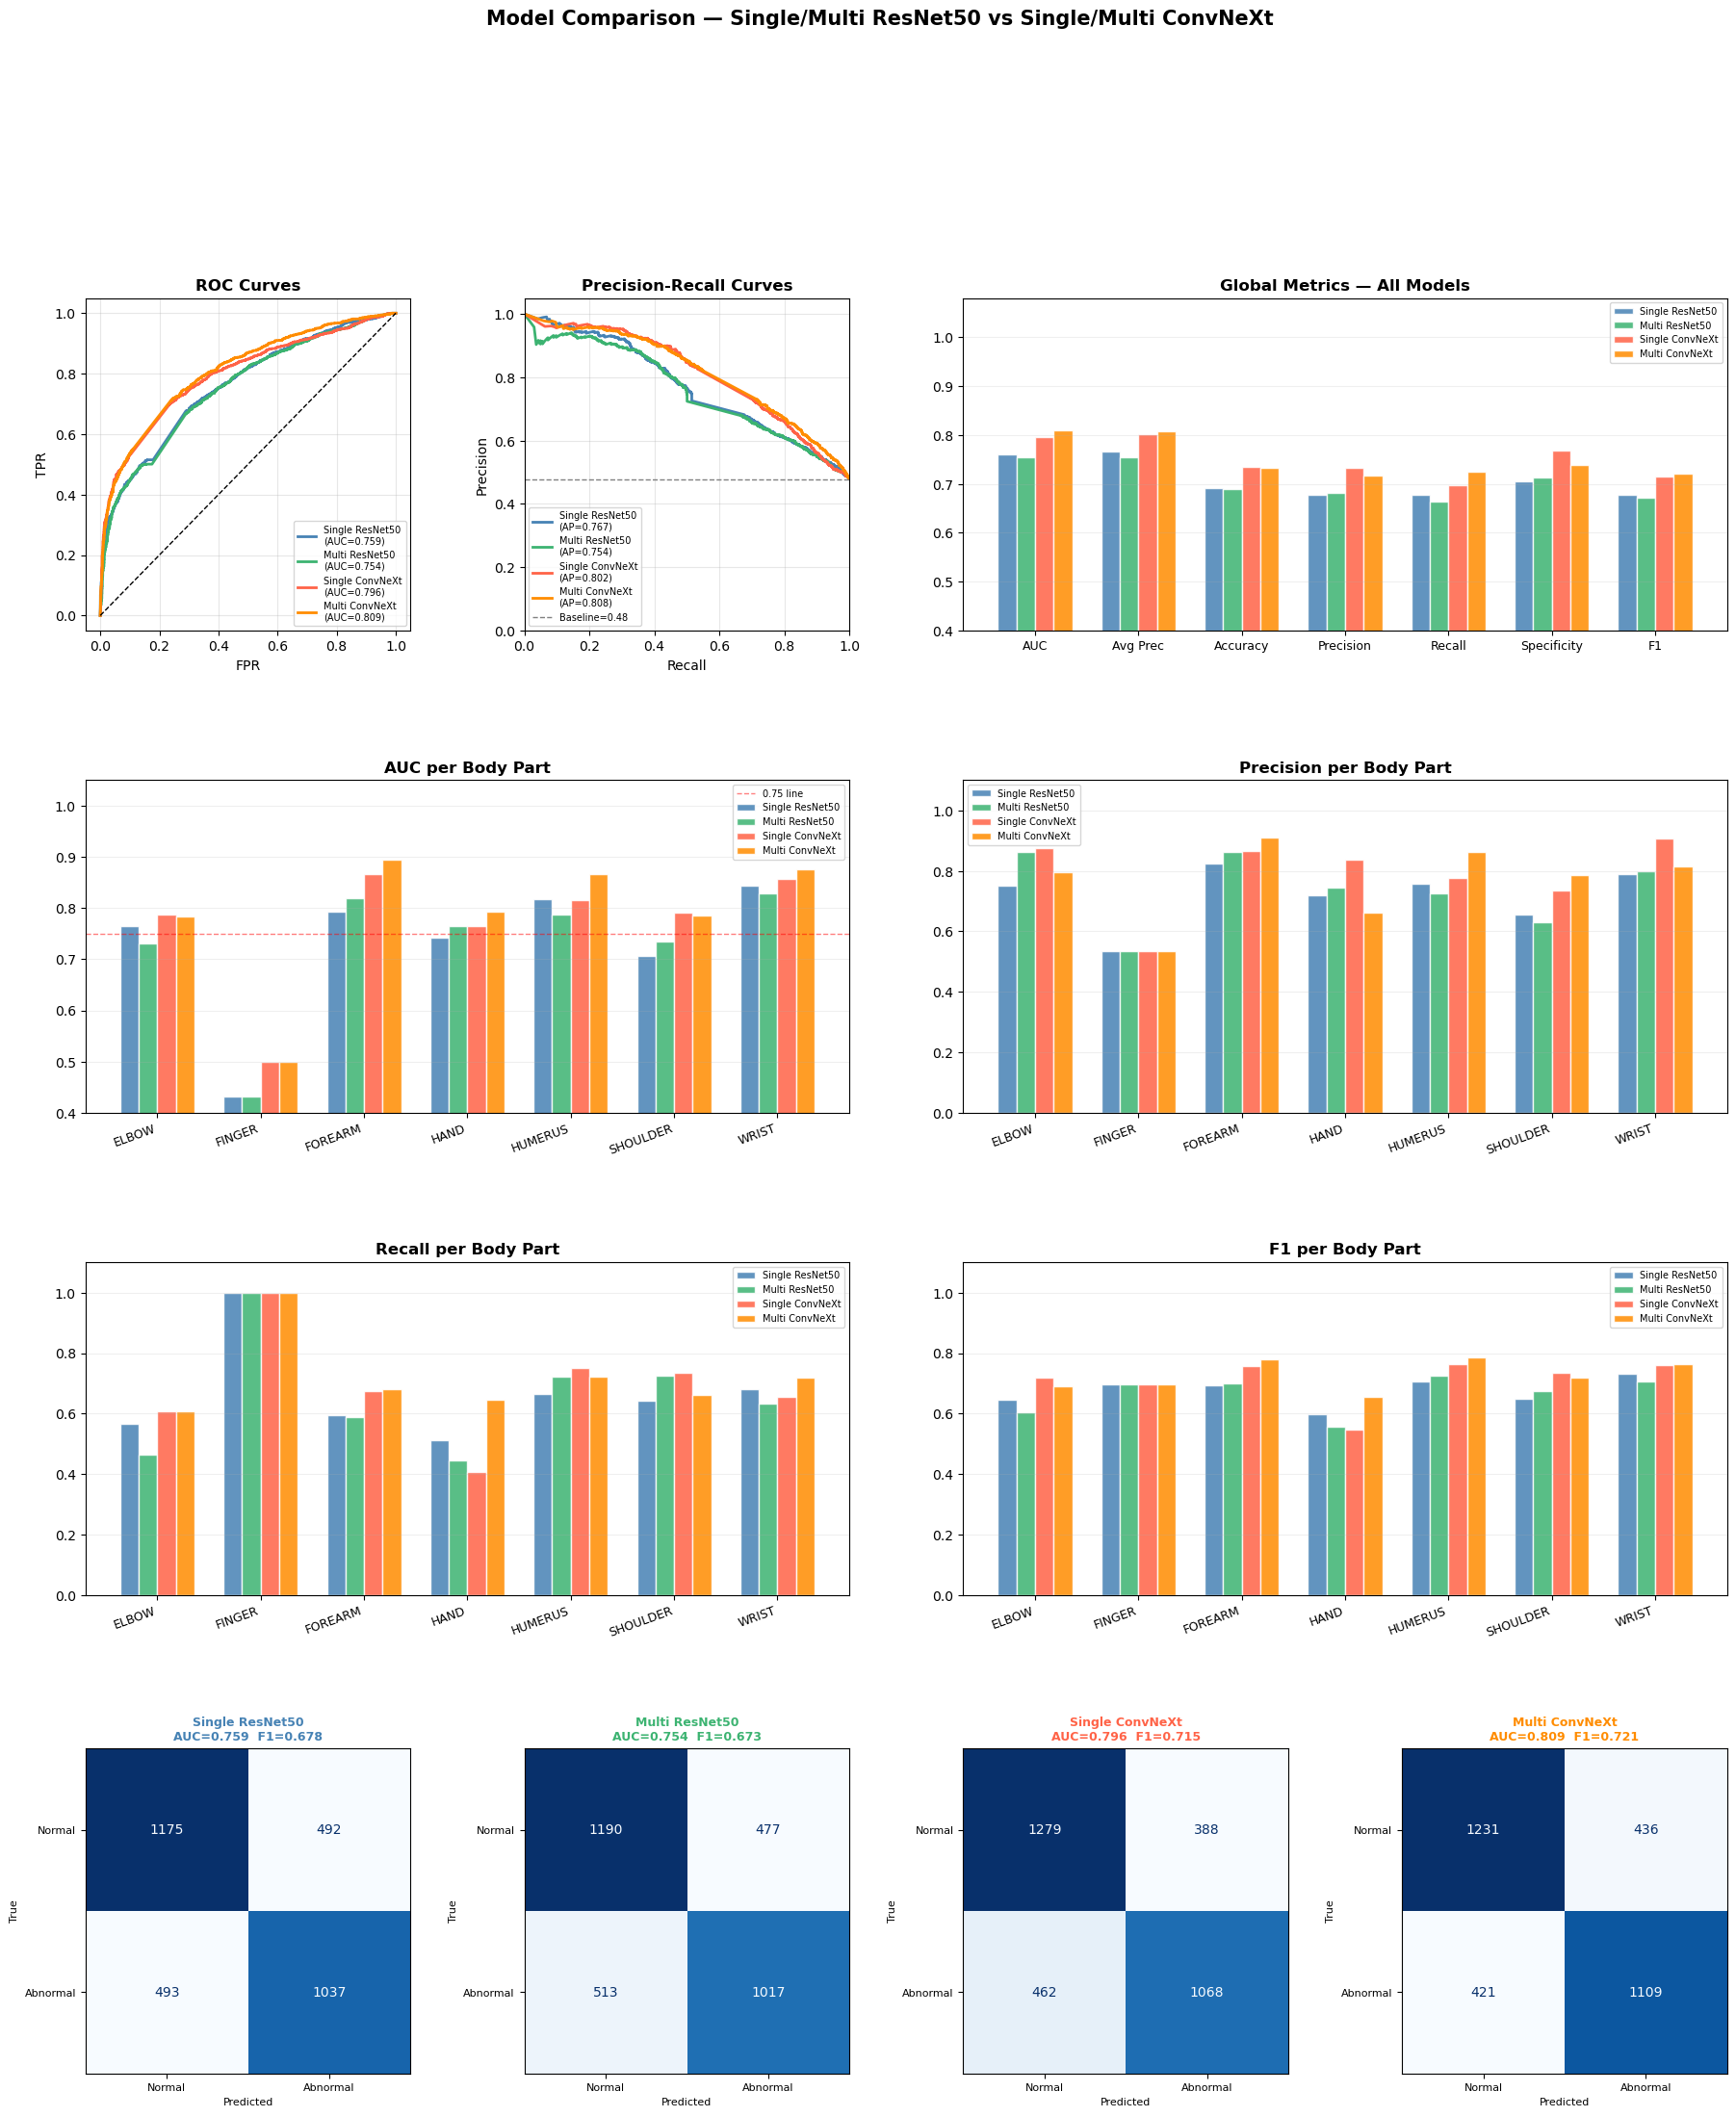

In [98]:
# ═══════════════════════════════════════════════════════════════════
# PLOTS — fixed layout, no overlapping
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 24))

# Row 1: ROC | PR Curve | Global Metrics
# Row 2: AUC per part | Precision per part | Recall per part
# Row 3: F1 per part | FN vs FP scatter | (empty)
# Row 4: 4 confusion matrices side by side

gs = fig.add_gridspec(4, 4, hspace=0.45, wspace=0.35,
                      height_ratios=[1, 1, 1, 1])

# ── Row 1 ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])   # ROC
ax2 = fig.add_subplot(gs[0, 1])   # PR curve
ax3 = fig.add_subplot(gs[0, 2:])  # Global metrics bar

# ── Row 2 ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2]) # AUC per body part
ax5 = fig.add_subplot(gs[1, 2:])  # Precision per body part

# ── Row 3 ─────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2]) # Recall per body part
ax7 = fig.add_subplot(gs[2, 2:])  # F1 per body part

# ── Row 4: one confusion matrix per model ─────────────────────────
ax_cm = [fig.add_subplot(gs[3, i]) for i in range(4)]

bar_w = 0.18
x     = np.arange(len(all_bp))

MODEL_REGISTRY = [
    ("Single ResNet50",   single_resnet,   val_loader_s1, False),
    ("Multi ResNet50",    multi_resnet,    val_loader_s1, True),
    ("Single ConvNeXt",  single_convnext,   val_loader_s1, False),
    ("Multi ConvNeXt",   multi_convnext,    val_loader_s1, True),
]

COLORS = ['steelblue', 'mediumseagreen', 'tomato', 'darkorange']


# ── 1. ROC ────────────────────────────────────────────────────────
for (name, *_), color in zip(MODEL_REGISTRY, COLORS):
    r = results[name]
    fpr, tpr, _ = roc_curve(r['true'], r['probs'])
    ax1.plot(fpr, tpr, lw=2, label=f"{name}\n(AUC={r['metrics']['auc']:.3f})", color=color)
ax1.plot([0,1],[0,1], 'k--', lw=1)
ax1.set_title('ROC Curves', fontweight='bold')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# ── 2. Precision-Recall ───────────────────────────────────────────
for (name, *_), color in zip(MODEL_REGISTRY, COLORS):
    r = results[name]
    prec, rec, _ = precision_recall_curve(r['true'], r['probs'])
    ap = r['metrics']['avg_precision']
    ax2.plot(rec, prec, lw=2, label=f"{name}\n(AP={ap:.3f})", color=color)
baseline = results[model_names[0]]['true'].mean()
ax2.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.05])
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# ── 3. Global metrics bar ─────────────────────────────────────────
plot_keys   = ['auc','avg_precision','accuracy','precision','recall','specificity','f1']
plot_labels = ['AUC','Avg Prec','Accuracy','Precision','Recall','Specificity','F1']
xg = np.arange(len(plot_labels))
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['metrics'][k] for k in plot_keys]
    offset = (i - 1.5) * 0.18
    ax3.bar(xg + offset, vals, 0.18, label=name, color=color, alpha=0.85, edgecolor='white')
ax3.set_xticks(xg)
ax3.set_xticklabels(plot_labels, fontsize=9)
ax3.set_ylim([0.4, 1.08])
ax3.set_title('Global Metrics — All Models', fontweight='bold')
ax3.legend(fontsize=7); ax3.grid(alpha=0.2, axis='y')

# ── 4. AUC per body part ──────────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('auc', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax4.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax4.axhline(0.75, color='red', linestyle='--', lw=1, alpha=0.5, label='0.75 line')
ax4.set_xticks(x); ax4.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax4.set_ylim([0.4, 1.05])
ax4.set_title('AUC per Body Part', fontweight='bold')
ax4.legend(fontsize=7); ax4.grid(alpha=0.2, axis='y')

# ── 5. Precision per body part ────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('precision', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax5.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax5.set_xticks(x); ax5.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax5.set_ylim([0, 1.1])
ax5.set_title('Precision per Body Part', fontweight='bold')
ax5.legend(fontsize=7); ax5.grid(alpha=0.2, axis='y')

# ── 6. Recall per body part ───────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('recall', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax6.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax6.set_xticks(x); ax6.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax6.set_ylim([0, 1.1])
ax6.set_title('Recall per Body Part', fontweight='bold')
ax6.legend(fontsize=7); ax6.grid(alpha=0.2, axis='y')

# ── 7. F1 per body part ───────────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('f1', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax7.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax7.set_xticks(x); ax7.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax7.set_ylim([0, 1.1])
ax7.set_title('F1 per Body Part', fontweight='bold')
ax7.legend(fontsize=7); ax7.grid(alpha=0.2, axis='y')

# ── 8. Confusion matrices — one per subplot, full row ─────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    ax  = ax_cm[i]
    preds = (results[name]['probs'] >= 0.5).astype(int)
    cm    = confusion_matrix(results[name]['true'], preds)
    m     = results[name]['metrics']
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAUC={m['auc']:.3f}  F1={m['f1']:.3f}",
                 fontsize=9, fontweight='bold', color=color)
    ax.tick_params(labelsize=8)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)

plt.suptitle('Model Comparison — Single/Multi ResNet50 vs Single/Multi ConvNeXt',
             fontsize=15, fontweight='bold', y=1.005)
plt.savefig('model_comparison_full_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

In [99]:
# Strategy 2
# single resnet
for epoch in range(1, num_epochs + 1):
    train_loss = train_single(single_resnet, train_loader_s2, single_resnet_optimizer, single_resnet_abnormal_loss_fn)
    m          = validate_single(single_resnet, val_loader_s2, single_resnet_abnormal_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | ...")




Epoch 01/20 | train_loss: 0.6085 | ...
Epoch 02/20 | train_loss: 0.6065 | ...
Epoch 03/20 | train_loss: 0.6060 | ...
Epoch 04/20 | train_loss: 0.6047 | ...
Epoch 05/20 | train_loss: 0.6039 | ...
Epoch 06/20 | train_loss: 0.5982 | ...
Epoch 07/20 | train_loss: 0.5979 | ...
Epoch 08/20 | train_loss: 0.5950 | ...
Epoch 09/20 | train_loss: 0.5963 | ...
Epoch 10/20 | train_loss: 0.5933 | ...
Epoch 11/20 | train_loss: 0.5921 | ...
Epoch 12/20 | train_loss: 0.5908 | ...
Epoch 13/20 | train_loss: 0.5891 | ...
Epoch 14/20 | train_loss: 0.5863 | ...
Epoch 15/20 | train_loss: 0.5868 | ...
Epoch 16/20 | train_loss: 0.5876 | ...
Epoch 17/20 | train_loss: 0.5860 | ...
Epoch 18/20 | train_loss: 0.5871 | ...
Epoch 19/20 | train_loss: 0.5846 | ...
Epoch 20/20 | train_loss: 0.5820 | ...


In [ ]:
# multi resnet
for epoch in range(1, num_epochs + 1):
    train_loss = train_multi(multi_resnet, train_loader_s2, multi_resnet_optimizer, multi_resnet_abnormal_loss_fn, multi_resnet_body_loss_fn)
    m          = validate_multi(multi_resnet, val_loader_s2, multi_resnet_abnormal_loss_fn, multi_resnet_body_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | ...")




Epoch 01/20 | train_loss: 2.0236 | ...


In [ ]:
# single convnext
for epoch in range(1, num_epochs + 1):
    train_loss = train_single(single_convnext, train_loader_s2, single_convnext_optimizer, single_convnext_abnormal_loss_fn)
    m          = validate_single(single_convnext, val_loader_s2, single_convnext_abnormal_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | ...")


In [ ]:
# multi convnext
for epoch in range(1, num_epochs + 1):
    train_loss = train_multi(multi_convnext, train_loader_s2, single_convnext_optimizer, single_convnext_abnormal_loss_fn)
    m          = validate_multi(multi_convnext, val_loader_s2, single_convnext_abnormal_loss_fn)
    print(f"Epoch {epoch:02d}/{num_epochs} | train_loss: {train_loss:.4f} | ...")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# PLOTS — fixed layout, no overlapping
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 24))

# Row 1: ROC | PR Curve | Global Metrics
# Row 2: AUC per part | Precision per part | Recall per part
# Row 3: F1 per part | FN vs FP scatter | (empty)
# Row 4: 4 confusion matrices side by side

gs = fig.add_gridspec(4, 4, hspace=0.45, wspace=0.35,
                      height_ratios=[1, 1, 1, 1])

# ── Row 1 ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])   # ROC
ax2 = fig.add_subplot(gs[0, 1])   # PR curve
ax3 = fig.add_subplot(gs[0, 2:])  # Global metrics bar

# ── Row 2 ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2]) # AUC per body part
ax5 = fig.add_subplot(gs[1, 2:])  # Precision per body part

# ── Row 3 ─────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2]) # Recall per body part
ax7 = fig.add_subplot(gs[2, 2:])  # F1 per body part

# ── Row 4: one confusion matrix per model ─────────────────────────
ax_cm = [fig.add_subplot(gs[3, i]) for i in range(4)]

bar_w = 0.18
x     = np.arange(len(all_bp))

MODEL_REGISTRY = [
    ("Single ResNet50",   single_resnet50,   val_loader_s2, False),
    ("Multi ResNet50",    multi_resnet50,    val_loader_s2, True),
    ("Single ConvNeXt",  single_convnext,   val_loader_s2, False),
    ("Multi ConvNeXt",   multi_convnext,    val_loader_s2, True),
]

COLORS = ['steelblue', 'mediumseagreen', 'tomato', 'darkorange']

# ── 1. ROC ────────────────────────────────────────────────────────
for (name, *_), color in zip(MODEL_REGISTRY, COLORS):
    r = results[name]
    fpr, tpr, _ = roc_curve(r['true'], r['probs'])
    ax1.plot(fpr, tpr, lw=2, label=f"{name}\n(AUC={r['metrics']['auc']:.3f})", color=color)
ax1.plot([0,1],[0,1], 'k--', lw=1)
ax1.set_title('ROC Curves', fontweight='bold')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# ── 2. Precision-Recall ───────────────────────────────────────────
for (name, *_), color in zip(MODEL_REGISTRY, COLORS):
    r = results[name]
    prec, rec, _ = precision_recall_curve(r['true'], r['probs'])
    ap = r['metrics']['avg_precision']
    ax2.plot(rec, prec, lw=2, label=f"{name}\n(AP={ap:.3f})", color=color)
baseline = results[model_names[0]]['true'].mean()
ax2.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.05])
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# ── 3. Global metrics bar ─────────────────────────────────────────
plot_keys   = ['auc','avg_precision','accuracy','precision','recall','specificity','f1']
plot_labels = ['AUC','Avg Prec','Accuracy','Precision','Recall','Specificity','F1']
xg = np.arange(len(plot_labels))
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['metrics'][k] for k in plot_keys]
    offset = (i - 1.5) * 0.18
    ax3.bar(xg + offset, vals, 0.18, label=name, color=color, alpha=0.85, edgecolor='white')
ax3.set_xticks(xg)
ax3.set_xticklabels(plot_labels, fontsize=9)
ax3.set_ylim([0.4, 1.08])
ax3.set_title('Global Metrics — All Models', fontweight='bold')
ax3.legend(fontsize=7); ax3.grid(alpha=0.2, axis='y')

# ── 4. AUC per body part ──────────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('auc', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax4.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax4.axhline(0.75, color='red', linestyle='--', lw=1, alpha=0.5, label='0.75 line')
ax4.set_xticks(x); ax4.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax4.set_ylim([0.4, 1.05])
ax4.set_title('AUC per Body Part', fontweight='bold')
ax4.legend(fontsize=7); ax4.grid(alpha=0.2, axis='y')

# ── 5. Precision per body part ────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('precision', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax5.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax5.set_xticks(x); ax5.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax5.set_ylim([0, 1.1])
ax5.set_title('Precision per Body Part', fontweight='bold')
ax5.legend(fontsize=7); ax5.grid(alpha=0.2, axis='y')

# ── 6. Recall per body part ───────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('recall', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax6.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax6.set_xticks(x); ax6.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax6.set_ylim([0, 1.1])
ax6.set_title('Recall per Body Part', fontweight='bold')
ax6.legend(fontsize=7); ax6.grid(alpha=0.2, axis='y')

# ── 7. F1 per body part ───────────────────────────────────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    vals   = [results[name]['per_part'].get(bp, {}).get('f1', 0.0) for bp in all_bp]
    offset = (i - 1.5) * bar_w
    ax7.bar(x + offset, vals, bar_w, label=name, color=color, alpha=0.85, edgecolor='white')
ax7.set_xticks(x); ax7.set_xticklabels(all_bp, rotation=20, ha='right', fontsize=9)
ax7.set_ylim([0, 1.1])
ax7.set_title('F1 per Body Part', fontweight='bold')
ax7.legend(fontsize=7); ax7.grid(alpha=0.2, axis='y')

# ── 8. Confusion matrices — one per subplot, full row ─────────────
for i, ((name, *_), color) in enumerate(zip(MODEL_REGISTRY, COLORS)):
    ax  = ax_cm[i]
    preds = (results[name]['probs'] >= 0.5).astype(int)
    cm    = confusion_matrix(results[name]['true'], preds)
    m     = results[name]['metrics']
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAUC={m['auc']:.3f}  F1={m['f1']:.3f}",
                 fontsize=9, fontweight='bold', color=color)
    ax.tick_params(labelsize=8)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)

plt.suptitle('Model Comparison — Single/Multi ResNet50 vs Single/Multi ConvNeXt',
             fontsize=15, fontweight='bold', y=1.005)
plt.savefig('model_comparison_full_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

Metric                 Strategy 1     Strategy 2      Delta
--------------------------------------------------------------
auc                        0.7963         0.7963    0.0000
avg_precision              0.8022         0.8022    0.0000
accuracy                   0.7341         0.7341    0.0000
sensitivity                0.6980         0.6980    0.0000
specificity                0.7672         0.7672    0.0000
precision                  0.7335         0.7335    0.0000
recall                     0.6980         0.6980    0.0000
f1                         0.7153         0.7153    0.0000

Body Part      S1 Prec   S1 Rec   S1 F1   S1 AP   S2 Prec   S2 Rec   S2 F1   S2 AP
--------------------------------------------------------------------------------
ELBOW            0.875    0.609   0.718   0.839      0.875    0.609   0.718   0.839
FINGER           0.536    1.000   0.698   0.536      0.536    1.000   0.698   0.536
FOREARM          0.864    0.675   0.758   0.889      0.864    0.675   0.

NameError: name 'roc_curve' is not defined

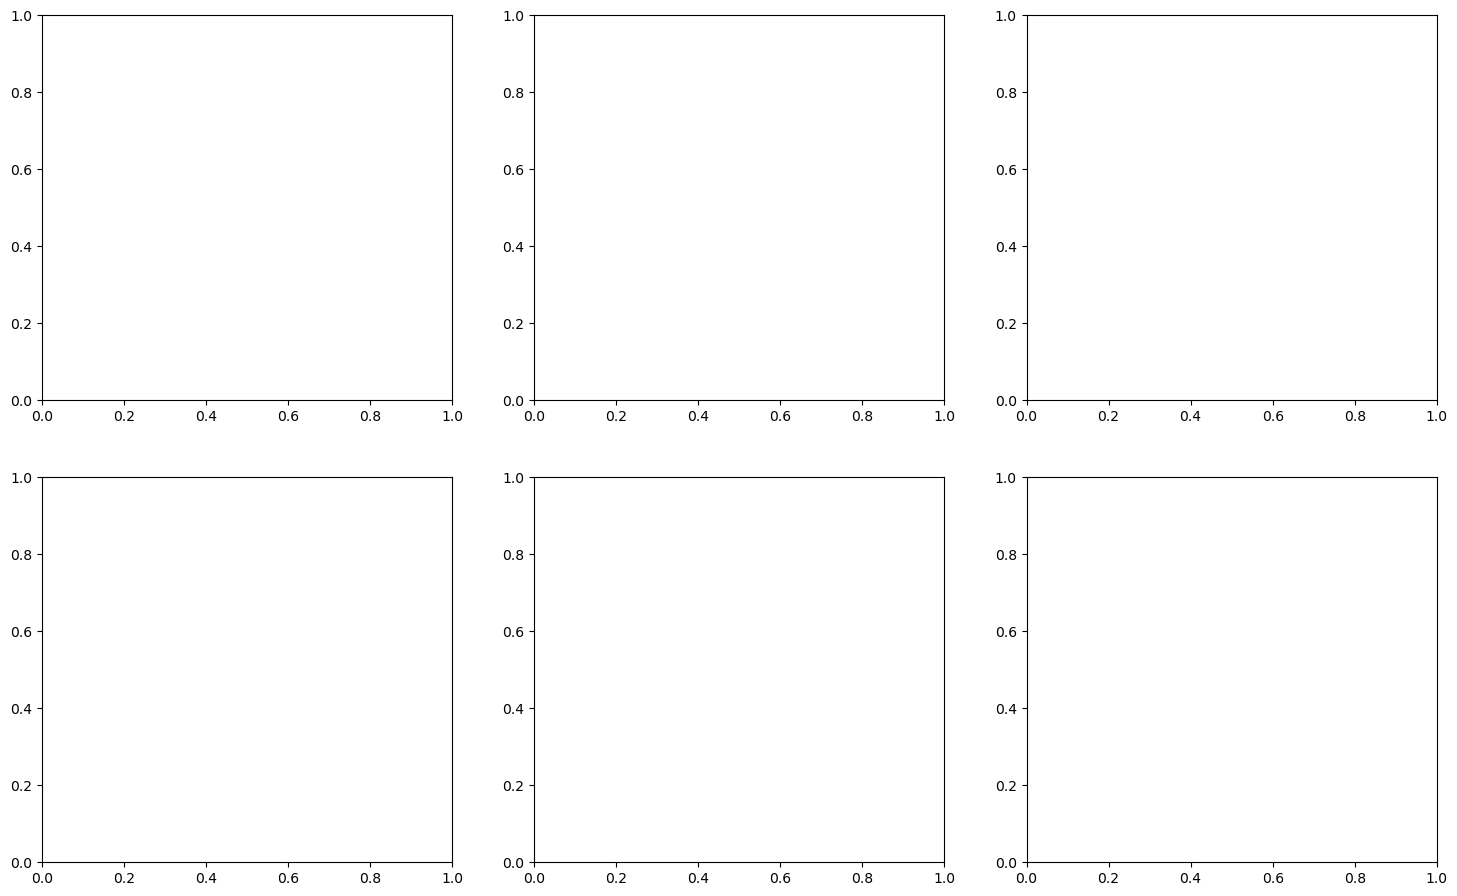

In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def get_predictions(model, loader):
    model.eval()
    all_probs, all_true, all_parts = [], [], []
    with torch.no_grad():
        for imgs, labels, body_parts in loader:
            imgs   = imgs.to(device)
            logits = model(imgs)
            if isinstance(logits, tuple):
                _, logits = logits
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_true.extend(labels.numpy())
            all_parts.extend(body_parts.numpy())
    return np.array(all_probs), np.array(all_true), np.array(all_parts)

def compute_metrics(probs, true, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'auc'        : roc_auc_score(true, probs),
        'avg_precision': average_precision_score(true, probs),   # area under PR curve
        'accuracy'   : accuracy_score(true, preds),
        'sensitivity': recall_score(true, preds, zero_division=0),     # recall = sensitivity
        'specificity': (((true == 0) & (preds == 0)).sum() /
                        (true == 0).sum()) if (true == 0).sum() > 0 else 0.0,
        'precision'  : precision_score(true, preds, zero_division=0),  # PPV = precision
        'recall'     : recall_score(true, preds, zero_division=0),
        'f1'         : f1_score(true, preds, zero_division=0),
    }

def compute_per_part(probs, true, parts, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    result = {}
    for part_id, part_name in body_part_names.items():
        mask = (parts == part_id)
        if mask.sum() < 5 or len(np.unique(true[mask])) < 2:
            continue
        try:
            auc = roc_auc_score(true[mask], probs[mask])
            ap  = average_precision_score(true[mask], probs[mask])
        except ValueError:
            auc, ap = 0.0, 0.0
        result[part_name] = {
            'auc'      : auc,
            'ap'       : ap,
            'precision': precision_score(true[mask], preds[mask], zero_division=0),
            'recall'   : recall_score(true[mask], preds[mask], zero_division=0),
            'f1'       : f1_score(true[mask], preds[mask], zero_division=0),
            'n'        : int(mask.sum()),
        }
    return result

# ── Get predictions ───────────────────────────────────────────────────────────
probs_s1, true_s1, parts_s1 = get_predictions(single_convnext, val_loader_s1)
probs_s2, true_s2, parts_s2 = get_predictions(single_convnext, val_loader_s2)

# For multi_convnext — uncomment:
# probs_s1, true_s1, parts_s1 = get_predictions(multi_convnext, val_loader_s1)
# probs_s2, true_s2, parts_s2 = get_predictions(multi_convnext, val_loader_s2)

m_s1  = compute_metrics(probs_s1, true_s1)
m_s2  = compute_metrics(probs_s2, true_s2)
pp_s1 = compute_per_part(probs_s1, true_s1, parts_s1)
pp_s2 = compute_per_part(probs_s2, true_s2, parts_s2)

# ── Global metrics table ──────────────────────────────────────────────────────
print("=" * 62)
print(f"{'Metric':<18} {'Strategy 1':>14} {'Strategy 2':>14} {'Delta':>10}")
print("-" * 62)
for metric in ['auc', 'avg_precision', 'accuracy', 'sensitivity',
               'specificity', 'precision', 'recall', 'f1']:
    v1    = m_s1[metric]
    v2    = m_s2[metric]
    delta = v2 - v1
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else ' ')
    print(f"{metric:<18} {v1:>14.4f} {v2:>14.4f} {arrow}{abs(delta):>8.4f}")
print("=" * 62)

# ── Per-body-part table ───────────────────────────────────────────────────────
print(f"\n{'Body Part':<12} {'S1 Prec':>9} {'S1 Rec':>8} {'S1 F1':>7} {'S1 AP':>7} "
      f"{'S2 Prec':>9} {'S2 Rec':>8} {'S2 F1':>7} {'S2 AP':>7}")
print("-" * 80)
for bp in sorted(set(list(pp_s1.keys()) + list(pp_s2.keys()))):
    s1 = pp_s1.get(bp, {})
    s2 = pp_s2.get(bp, {})
    print(f"{bp:<12} "
          f"{s1.get('precision',0):>9.3f} {s1.get('recall',0):>8.3f} "
          f"{s1.get('f1',0):>7.3f} {s1.get('ap',0):>7.3f}  "
          f"{s2.get('precision',0):>9.3f} {s2.get('recall',0):>8.3f} "
          f"{s2.get('f1',0):>7.3f} {s2.get('ap',0):>7.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. ROC curves
ax = axes[0, 0]
for probs, true, label, color in [
    (probs_s1, true_s1, 'Strategy 1', 'steelblue'),
    (probs_s2, true_s2, 'Strategy 2', 'tomato'),
]:
    fpr, tpr, _ = roc_curve(true, probs)
    auc = roc_auc_score(true, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.4f})', color=color)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_title('ROC Curve — S1 vs S2', fontweight='bold')
ax.set_xlabel('FPR (1 - Specificity)'); ax.set_ylabel('TPR (Recall)')
ax.legend(); ax.grid(alpha=0.3)

# 2. Precision-Recall curves  ← NEW
ax = axes[0, 1]
for probs, true, label, color in [
    (probs_s1, true_s1, 'Strategy 1', 'steelblue'),
    (probs_s2, true_s2, 'Strategy 2', 'tomato'),
]:
    prec, rec, _ = precision_recall_curve(true, probs)
    ap = average_precision_score(true, probs)
    ax.plot(rec, prec, lw=2, label=f'{label} (AP={ap:.4f})', color=color)
baseline = true_s1.mean()
ax.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_title('Precision-Recall Curve — S1 vs S2', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.legend(); ax.grid(alpha=0.3)

# 3. Global metrics bar chart — now includes precision & recall
ax = axes[0, 2]
metric_names = ['AUC', 'Avg Prec', 'Accuracy', 'Sensitivity\n(Recall)', 'Specificity', 'Precision', 'F1']
metric_keys  = ['auc', 'avg_precision', 'accuracy', 'recall', 'specificity', 'precision', 'f1']
s1_vals = [m_s1[k] for k in metric_keys]
s2_vals = [m_s2[k] for k in metric_keys]
x = np.arange(len(metric_names)); w = 0.35
ax.bar(x-w/2, s1_vals, w, label='S1', color='steelblue', alpha=0.85, edgecolor='white')
ax.bar(x+w/2, s2_vals, w, label='S2', color='tomato',    alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=8, rotation=15, ha='right')
ax.set_ylim([0.4, 1.05]); ax.legend()
ax.set_title('All Metrics — S1 vs S2', fontweight='bold')

# 4. Per-body-part Precision vs Recall — S1  ← NEW
ax = axes[1, 0]
bp_names = list(pp_s1.keys())
prec_vals = [pp_s1[bp]['precision'] for bp in bp_names]
rec_vals  = [pp_s1[bp]['recall']    for bp in bp_names]
x = np.arange(len(bp_names)); w = 0.38
ax.bar(x-w/2, prec_vals, w, label='Precision', color='mediumseagreen', alpha=0.85, edgecolor='white')
ax.bar(x+w/2, rec_vals,  w, label='Recall',    color='darkorange',     alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(bp_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim([0, 1.1]); ax.legend()
ax.set_title('Precision vs Recall per Body Part — S1', fontweight='bold')

# 5. Per-body-part Precision vs Recall — S2  ← NEW
ax = axes[1, 1]
bp_names2 = list(pp_s2.keys())
prec_vals2 = [pp_s2[bp]['precision'] for bp in bp_names2]
rec_vals2  = [pp_s2[bp]['recall']    for bp in bp_names2]
x2 = np.arange(len(bp_names2)); 
ax.bar(x2-w/2, prec_vals2, w, label='Precision', color='mediumseagreen', alpha=0.85, edgecolor='white')
ax.bar(x2+w/2, rec_vals2,  w, label='Recall',    color='darkorange',     alpha=0.85, edgecolor='white')
ax.set_xticks(x2); ax.set_xticklabels(bp_names2, rotation=20, ha='right', fontsize=9)
ax.set_ylim([0, 1.1]); ax.legend()
ax.set_title('Precision vs Recall per Body Part — S2', fontweight='bold')

# 6. Confusion matrices
ax = axes[1, 2]
ax.axis('off')
for i, (probs, true, label) in enumerate([
    (probs_s1, true_s1, 'S1'), (probs_s2, true_s2, 'S2')
]):
    preds = (probs >= 0.5).astype(int)
    cm    = confusion_matrix(true, preds)
    sub   = fig.add_axes([0.67 + i*0.165, 0.08, 0.14, 0.28])
    ConfusionMatrixDisplay(cm, display_labels=['Norm','Abnorm']).plot(
        ax=sub, colorbar=False, cmap='Blues')
    sub.set_title(f'Confusion\n{label}', fontsize=9, fontweight='bold')
    sub.tick_params(labelsize=7)
    sub.set_xlabel('Predicted', fontsize=7)
    sub.set_ylabel('True', fontsize=7)

plt.suptitle('Single ConvNeXt — S1 vs S2 Full Metrics (with Precision & Recall)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('convnext_full_metrics_pr.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def get_predictions(model, loader):
    model.eval()
    all_probs, all_true, all_parts = [], [], []
    with torch.no_grad():
        for imgs, labels, body_parts in loader:
            imgs   = imgs.to(device)
            logits = model(imgs)
            if isinstance(logits, tuple):
                _, logits = logits
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_true.extend(labels.numpy())
            all_parts.extend(body_parts.numpy())
    return np.array(all_probs), np.array(all_true), np.array(all_parts)

def compute_metrics(probs, true, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'auc'        : roc_auc_score(true, probs),
        'avg_precision': average_precision_score(true, probs),   # area under PR curve
        'accuracy'   : accuracy_score(true, preds),
        'sensitivity': recall_score(true, preds, zero_division=0),     # recall = sensitivity
        'specificity': (((true == 0) & (preds == 0)).sum() /
                        (true == 0).sum()) if (true == 0).sum() > 0 else 0.0,
        'precision'  : precision_score(true, preds, zero_division=0),  # PPV = precision
        'recall'     : recall_score(true, preds, zero_division=0),
        'f1'         : f1_score(true, preds, zero_division=0),
    }

def compute_per_part(probs, true, parts, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    result = {}
    for part_id, part_name in body_part_names.items():
        mask = (parts == part_id)
        if mask.sum() < 5 or len(np.unique(true[mask])) < 2:
            continue
        try:
            auc = roc_auc_score(true[mask], probs[mask])
            ap  = average_precision_score(true[mask], probs[mask])
        except ValueError:
            auc, ap = 0.0, 0.0
        result[part_name] = {
            'auc'      : auc,
            'ap'       : ap,
            'precision': precision_score(true[mask], preds[mask], zero_division=0),
            'recall'   : recall_score(true[mask], preds[mask], zero_division=0),
            'f1'       : f1_score(true[mask], preds[mask], zero_division=0),
            'n'        : int(mask.sum()),
        }
    return result

# ── Get predictions ───────────────────────────────────────────────────────────
#probs_s1, true_s1, parts_s1 = get_predictions(single_convnext, val_loader_s1)
#probs_s2, true_s2, parts_s2 = get_predictions(single_convnext, val_loader_s2)

# For multi_convnext — uncomment:
probs_s1, true_s1, parts_s1 = get_predictions(multi_convnext, val_loader_s1)
probs_s2, true_s2, parts_s2 = get_predictions(multi_convnext, val_loader_s2)

m_s1  = compute_metrics(probs_s1, true_s1)
m_s2  = compute_metrics(probs_s2, true_s2)
pp_s1 = compute_per_part(probs_s1, true_s1, parts_s1)
pp_s2 = compute_per_part(probs_s2, true_s2, parts_s2)

# ── Global metrics table ──────────────────────────────────────────────────────

print(f"{'Metric':<18} {'Strategy 1':>14} {'Strategy 2':>14} {'Delta':>10}")
print("-" * 62)
for metric in ['auc', 'avg_precision', 'accuracy', 'sensitivity',
               'specificity', 'precision', 'recall', 'f1']:
    v1    = m_s1[metric]
    v2    = m_s2[metric]
    delta = v2 - v1
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else ' ')
    print(f"{metric:<18} {v1:>14.4f} {v2:>14.4f} {arrow}{abs(delta):>8.4f}")
print("=" * 62)

# ── Per-body-part table ───────────────────────────────────────────────────────
print(f"\n{'Body Part':<12} {'S1 Prec':>9} {'S1 Rec':>8} {'S1 F1':>7} {'S1 AP':>7} "
      f"{'S2 Prec':>9} {'S2 Rec':>8} {'S2 F1':>7} {'S2 AP':>7}")
print("-" * 80)
for bp in sorted(set(list(pp_s1.keys()) + list(pp_s2.keys()))):
    s1 = pp_s1.get(bp, {})
    s2 = pp_s2.get(bp, {})
    print(f"{bp:<12} "
          f"{s1.get('precision',0):>9.3f} {s1.get('recall',0):>8.3f} "
          f"{s1.get('f1',0):>7.3f} {s1.get('ap',0):>7.3f}  "
          f"{s2.get('precision',0):>9.3f} {s2.get('recall',0):>8.3f} "
          f"{s2.get('f1',0):>7.3f} {s2.get('ap',0):>7.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. ROC curves
ax = axes[0, 0]
for probs, true, label, color in [
    (probs_s1, true_s1, 'Strategy 1', 'steelblue'),
    (probs_s2, true_s2, 'Strategy 2', 'tomato'),
]:
    fpr, tpr, _ = roc_curve(true, probs)
    auc = roc_auc_score(true, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.4f})', color=color)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_title('ROC Curve — S1 vs S2', fontweight='bold')
ax.set_xlabel('FPR (1 - Specificity)'); ax.set_ylabel('TPR (Recall)')
ax.legend(); ax.grid(alpha=0.3)

# 2. Precision-Recall curves  ← NEW
ax = axes[0, 1]
for probs, true, label, color in [
    (probs_s1, true_s1, 'Strategy 1', 'steelblue'),
    (probs_s2, true_s2, 'Strategy 2', 'tomato'),
]:
    prec, rec, _ = precision_recall_curve(true, probs)
    ap = average_precision_score(true, probs)
    ax.plot(rec, prec, lw=2, label=f'{label} (AP={ap:.4f})', color=color)
baseline = true_s1.mean()
ax.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_title('Precision-Recall Curve — S1 vs S2', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.legend(); ax.grid(alpha=0.3)

# 3. Global metrics bar chart — now includes precision & recall
ax = axes[0, 2]
metric_names = ['AUC', 'Avg Prec', 'Accuracy', 'Sensitivity\n(Recall)', 'Specificity', 'Precision', 'F1']
metric_keys  = ['auc', 'avg_precision', 'accuracy', 'recall', 'specificity', 'precision', 'f1']
s1_vals = [m_s1[k] for k in metric_keys]
s2_vals = [m_s2[k] for k in metric_keys]
x = np.arange(len(metric_names)); w = 0.35
ax.bar(x-w/2, s1_vals, w, label='S1', color='steelblue', alpha=0.85, edgecolor='white')
ax.bar(x+w/2, s2_vals, w, label='S2', color='tomato',    alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=8, rotation=15, ha='right')
ax.set_ylim([0.4, 1.05]); ax.legend()
ax.set_title('All Metrics — S1 vs S2', fontweight='bold')

# 4. Per-body-part Precision vs Recall — S1  ← NEW
ax = axes[1, 0]
bp_names = list(pp_s1.keys())
prec_vals = [pp_s1[bp]['precision'] for bp in bp_names]
rec_vals  = [pp_s1[bp]['recall']    for bp in bp_names]
x = np.arange(len(bp_names)); w = 0.38
ax.bar(x-w/2, prec_vals, w, label='Precision', color='mediumseagreen', alpha=0.85, edgecolor='white')
ax.bar(x+w/2, rec_vals,  w, label='Recall',    color='darkorange',     alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(bp_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim([0, 1.1]); ax.legend()
ax.set_title('Precision vs Recall per Body Part — S1', fontweight='bold')

# 5. Per-body-part Precision vs Recall — S2  ← NEW
ax = axes[1, 1]
bp_names2 = list(pp_s2.keys())
prec_vals2 = [pp_s2[bp]['precision'] for bp in bp_names2]
rec_vals2  = [pp_s2[bp]['recall']    for bp in bp_names2]
x2 = np.arange(len(bp_names2)); 
ax.bar(x2-w/2, prec_vals2, w, label='Precision', color='mediumseagreen', alpha=0.85, edgecolor='white')
ax.bar(x2+w/2, rec_vals2,  w, label='Recall',    color='darkorange',     alpha=0.85, edgecolor='white')
ax.set_xticks(x2); ax.set_xticklabels(bp_names2, rotation=20, ha='right', fontsize=9)
ax.set_ylim([0, 1.1]); ax.legend()
ax.set_title('Precision vs Recall per Body Part — S2', fontweight='bold')

# 6. Confusion matrices
ax = axes[1, 2]
ax.axis('off')
for i, (probs, true, label) in enumerate([
    (probs_s1, true_s1, 'S1'), (probs_s2, true_s2, 'S2')
]):
    preds = (probs >= 0.5).astype(int)
    cm    = confusion_matrix(true, preds)
    sub   = fig.add_axes([0.67 + i*0.165, 0.08, 0.14, 0.28])
    ConfusionMatrixDisplay(cm, display_labels=['Norm','Abnorm']).plot(
        ax=sub, colorbar=False, cmap='Blues')
    sub.set_title(f'Confusion\n{label}', fontsize=9, fontweight='bold')
    sub.tick_params(labelsize=7)
    sub.set_xlabel('Predicted', fontsize=7)
    sub.set_ylabel('True', fontsize=7)

plt.suptitle('Multi ConvNeXt — S1 vs S2 Full Metrics (with Precision & Recall)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('convnext_full_metrics_pr.png', bbox_inches='tight', dpi=150)
plt.show()

# <u> Metrics </u>
## **TO DO**
- present the metrics comparing our four models for overall accruacy, auc, sens, PPV, F1 for abnormality classification
- compare performance of body part detection for the multi models ResNet and Convnext
- turn metric into a table or png to export

In [ ]:
def print_metrics(model, loader, loss_fn, model_name, is_multi=False, body_loss_fn=None, body_part_names=None):
    # 1. Run Validation
    if is_multi:
        m = validate_multi(model, loader, loss_fn, body_loss_fn, body_part_names)
    else:
        m = validate_single(model, loader, loss_fn)

    # 2. Print Header
    print(f"\n{'━'*65}")
    print(f" MODEL: {model_name.upper()}")
    print(f"{'━'*65}")

    # 3. Print Global Abnormality Metrics
    print(f" [GLOBAL ABNORMALITY METRICS]")
    print(f"  Val Loss    : {m['val_loss']:.4f}")
    print(f"  AUC         : {m['auc']:.4f}")
    print(f"  Sensitivity : {m['sensitivity']:.4f}")
    print(f"  PPV (Prec.) : {m['ppv']:.4f}")
    print(f"  F1 Score    : {m['f1']:.4f}")

    if is_multi:
        print(f"\n [BODY PART CLASSIFICATION]")
        print(f"  Accuracy    : {m['body_accuracy']:.4f}")

        # 4. Print Per-Part Breakdown Table
        if 'per_part' in m and m['per_part']:
            print(f"\n {'─'*60}")
            print(f"  {'Body Part':<15} | {'AUC':<6} | {'Sens':<6} | {'PPV':<6} | {'F1':<6}")
            print(f" {'─'*60}")

            for part, scores in m['per_part'].items():
                print(f"  {part:<15} | {scores['auc']:.3f} | {scores['sensitivity']:.3f} | {scores['ppv']:.3f} | {scores['f1']:.3f}")
            print(f" {'─'*60}")

    print(f"{'━'*65}\n")

print_metrics(single_resnet,   val_loader_s1, single_resnet_abnormal_loss_fn,   "S1- Single ResNet50")
print_metrics(multi_resnet,    val_loader_s1, multi_resnet_abnormal_loss_fn,    "S1- Multi ResNet50",  is_multi=True, body_loss_fn=multi_resnet_body_loss_fn)
print_metrics(single_convnext, val_loader_s1, single_convnext_abnormal_loss_fn, "S1- Single ConvNeXt")
print_metrics(multi_convnext,  val_loader_s1, multi_convnext_abnormal_loss_fn,  "S1- Multi ConvNeXt",  is_multi=True, body_loss_fn=multi_convnext_body_loss_fn)


print_metrics(single_resnet,   val_loader_s2, single_resnet_abnormal_loss_fn,   "S1- Single ResNet50")
print_metrics(multi_resnet,    val_loader_s2, multi_resnet_abnormal_loss_fn,    "S2- Multi ResNet50",  is_multi=True, body_loss_fn=multi_resnet_body_loss_fn)
print_metrics(single_convnext, val_loader_s2, single_convnext_abnormal_loss_fn, "S2- Single ConvNeXt")
print_metrics(multi_convnext,  val_loader_s2, multi_convnext_abnormal_loss_fn,  "S2- Multi ConvNeXt",  is_multi=True, body_loss_fn=multi_convnext_body_loss_fn)

# <u> Apply Model to Test Datset (FracAtlas) </u>
### **TO DO**
Steps:
1. Load fracatlas
2. Preprocess fracatlas to the same format as MURA
3. Fit the model on this data
4. Calc the metrics